In [1]:
from dataclasses import dataclass
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import MCMCResult, nuts_sample
from ugdatalab.plotters.bayesian import plot_trace, plot_corner, plot_posterior_predictive

from plotters import plot_sampler_comparison_corner, _savefig


@dataclass(frozen=True)
class MHResult:
    """Result from the hand-written Metropolis-Hastings sampler."""
    samples: np.ndarray
    log_probs: np.ndarray
    labels: list
    acceptance_rate: float

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
data_path = Path("rrlyrae_calibration_sample.npz")
data = np.load(data_path, allow_pickle=True)
rrlyrae_clean_data = table.Table({k: data[k] for k in data.files})
classes = np.asarray(rrlyrae_clean_data["best_classification"]).astype(str)

rrab_data = rrlyrae_clean_data[classes == "RRab"]
rrc_data = rrlyrae_clean_data[classes == "RRc"]
rrd_data = rrlyrae_clean_data[classes == "RRd"]

In [3]:
DISPLAY_LABELS = [r"$a$", r"$b$", r"$\sigma_{\rm scatter}$"]
MH_PROPOSAL_AXES = [
    [0.004, 0.006, 0.008, 0.010],
    [0.008, 0.012, 0.016, 0.020],
    [0.008, 0.012, 0.016, 0.020],
]


def build_pl_context(data):
    """Build a centered PL context from calibration data for one subclass."""
    log_p = np.log10(data["rrlyrae_representative_period"])
    mean_log_p = np.mean(log_p)
    return {
        "x_centered": log_p - mean_log_p,
        "y": np.array(data["M_G"]),
        "sigma": np.array(data["sigma_M"]),
        "mean_log_p": mean_log_p,
        "intercept_prior_mean": np.median(data["M_G"]),
    }


def log_posterior_pl(theta, ctx):
    """Log-posterior for a linear PL model with intrinsic scatter."""
    a, b, log10_sigma = theta
    sigma_scatter = 10.0 ** log10_sigma

    # Likelihood
    sigma2_tot = ctx["sigma"]**2 + sigma_scatter**2
    mu = a * ctx["x_centered"] + b
    logL = -0.5 * np.sum(np.log(2 * np.pi * sigma2_tot) + (ctx["y"] - mu)**2 / sigma2_tot)

    # Priors: broad normal on a and b, half-normal on sigma_scatter
    logp_a = -0.5 * (a / 5.0)**2
    logp_b = -0.5 * ((b - ctx["intercept_prior_mean"]) / 1.0)**2
    logp_sigma = -0.5 * (sigma_scatter / 0.5)**2 + np.log(np.log(10.0) * sigma_scatter)
    return logL + logp_a + logp_b + logp_sigma


def run_mh_sampler(ctx, proposal_std, n_steps=25_000, n_burn=5_000, seed=42):
    """Run MH sampler on PL model, return MHResult in display space."""
    rng = np.random.default_rng(seed)
    theta = np.array([0.0, ctx["intercept_prior_mean"], np.log10(0.1)])
    samples = np.empty((n_steps, 3))
    log_probs = np.empty(n_steps)
    lp = log_posterior_pl(theta, ctx)
    n_acc = 0
    for i in range(n_steps):
        prop = theta + rng.normal(0, proposal_std)
        lp_prop = log_posterior_pl(prop, ctx)
        if np.log(rng.uniform()) < lp_prop - lp:
            theta, lp = prop, lp_prop
            n_acc += 1
        samples[i] = theta
        log_probs[i] = lp

    # Convert to display space: log10(sigma) -> sigma
    display_samples = samples.copy()
    display_samples[:, 2] = 10.0 ** display_samples[:, 2]
    return MHResult(
        samples=display_samples[n_burn:],
        log_probs=log_probs[n_burn:],
        labels=DISPLAY_LABELS,
        acceptance_rate=n_acc / n_steps,
    )


def to_display(result):
    """Convert an MCMCResult or MHResult to display space (log10_sig -> sig)."""
    display_samples = result.samples.copy()
    display_samples[:, 2] = 10.0 ** display_samples[:, 2]
    return MHResult(
        samples=display_samples,
        log_probs=result.log_probs,
        labels=DISPLAY_LABELS,
        acceptance_rate=getattr(result, "acceptance_rate", np.nan),
    )


def fit_nuts_potential(ctx, n_steps=2_000, n_burn=1_000, seed=42):
    """Fit PL model using NUTS with pm.Potential (manual log-likelihood)."""
    with pm.Model() as model:
        a = pm.Normal("a", mu=0, sigma=5)
        b = pm.Normal("b", mu=ctx["intercept_prior_mean"], sigma=1)
        log10_sig = pm.Normal("log10_sig", mu=np.log10(0.1), sigma=2)
        sigma_scatter = 10.0 ** log10_sig

        x = pt.as_tensor_variable(ctx["x_centered"])
        y = pt.as_tensor_variable(ctx["y"])
        sigma_obs = pt.as_tensor_variable(ctx["sigma"])
        sigma2_tot = sigma_obs**2 + sigma_scatter**2
        mu = a * x + b
        logL = -0.5 * pt.sum(pt.log(2 * np.pi * sigma2_tot) + (y - mu)**2 / sigma2_tot)
        pm.Potential("logL", logL)
        # Half-normal Jacobian for sigma_scatter
        pm.Potential("sigma_jacobian", pt.log(pt.log(10.0) * sigma_scatter)
                     - 0.5 * (sigma_scatter / 0.5)**2)

        trace = pm.sample(draws=n_steps, tune=n_burn, random_seed=seed, progressbar=False)

    var_names = ["a", "b", "log10_sig"]
    posterior = trace.posterior
    samples_raw = np.column_stack([posterior[v].values.flatten() for v in var_names])
    log_probs = trace.sample_stats["lp"].values.flatten()

    return MCMCResult(
        theta=np.median(samples_raw, axis=0),
        samples=samples_raw,
        log_probs=log_probs,
        labels=[r"$a$", r"$b$", r"$\log_{10}\,\sigma_s$"],
        chi2_r=np.nan,
    )


def fit_nuts_native(ctx, n_steps=2_000, n_burn=1_000, seed=42):
    """Fit PL model using native PyMC NUTS via LinearGaussianLikelihood."""
    likelihood = LinearGaussianLikelihood(
        x=ctx["x_centered"], y=ctx["y"], y_err=ctx["sigma"],
    )
    return nuts_sample(likelihood, n_steps=n_steps, n_burn=n_burn, seed=seed)


# --- Build contexts ---
rrab_data = rrlyrae_clean_data[rrlyrae_clean_data["best_classification"] == "RRab"]
rrc_data = rrlyrae_clean_data[rrlyrae_clean_data["best_classification"] == "RRc"]
rrd_data = rrlyrae_clean_data[rrlyrae_clean_data["best_classification"] == "RRd"]

rrab_ctx = build_pl_context(rrab_data)
rrc_ctx = build_pl_context(rrc_data)

In [4]:
from itertools import product

rrab_proposal_scan = []
for s_a, s_b, s_sig in product(*MH_PROPOSAL_AXES):
    ps = np.array([s_a, s_b, s_sig])
    result = run_mh_sampler(rrab_ctx, ps, n_steps=4_000, n_burn=500)
    rrab_proposal_scan.append({
        "s_a": s_a, "s_b": s_b, "s_sig": s_sig,
        "acceptance": round(result.acceptance_rate, 3),
    })
rrab_proposal_scan = pd.DataFrame(rrab_proposal_scan)

best_row = rrab_proposal_scan.loc[(rrab_proposal_scan["acceptance"] - 0.5).abs().idxmin()]
rrab_proposal_std = np.array([best_row["s_a"], best_row["s_b"], best_row["s_sig"]])
rrab_proposal_scan

,s_a,s_b,s_sig,acceptance
0,0.004,0.008,0.008,0.672
1,0.004,0.008,0.012,0.618
2,0.004,0.008,0.016,0.577
3,0.004,0.008,0.020,0.536
4,0.004,0.012,0.008,0.585
...,...,...,...,...
59,0.010,0.016,0.020,0.405
60,0.010,0.020,0.008,0.423
61,0.010,0.020,0.012,0.403
62,0.010,0.020,0.016,0.380


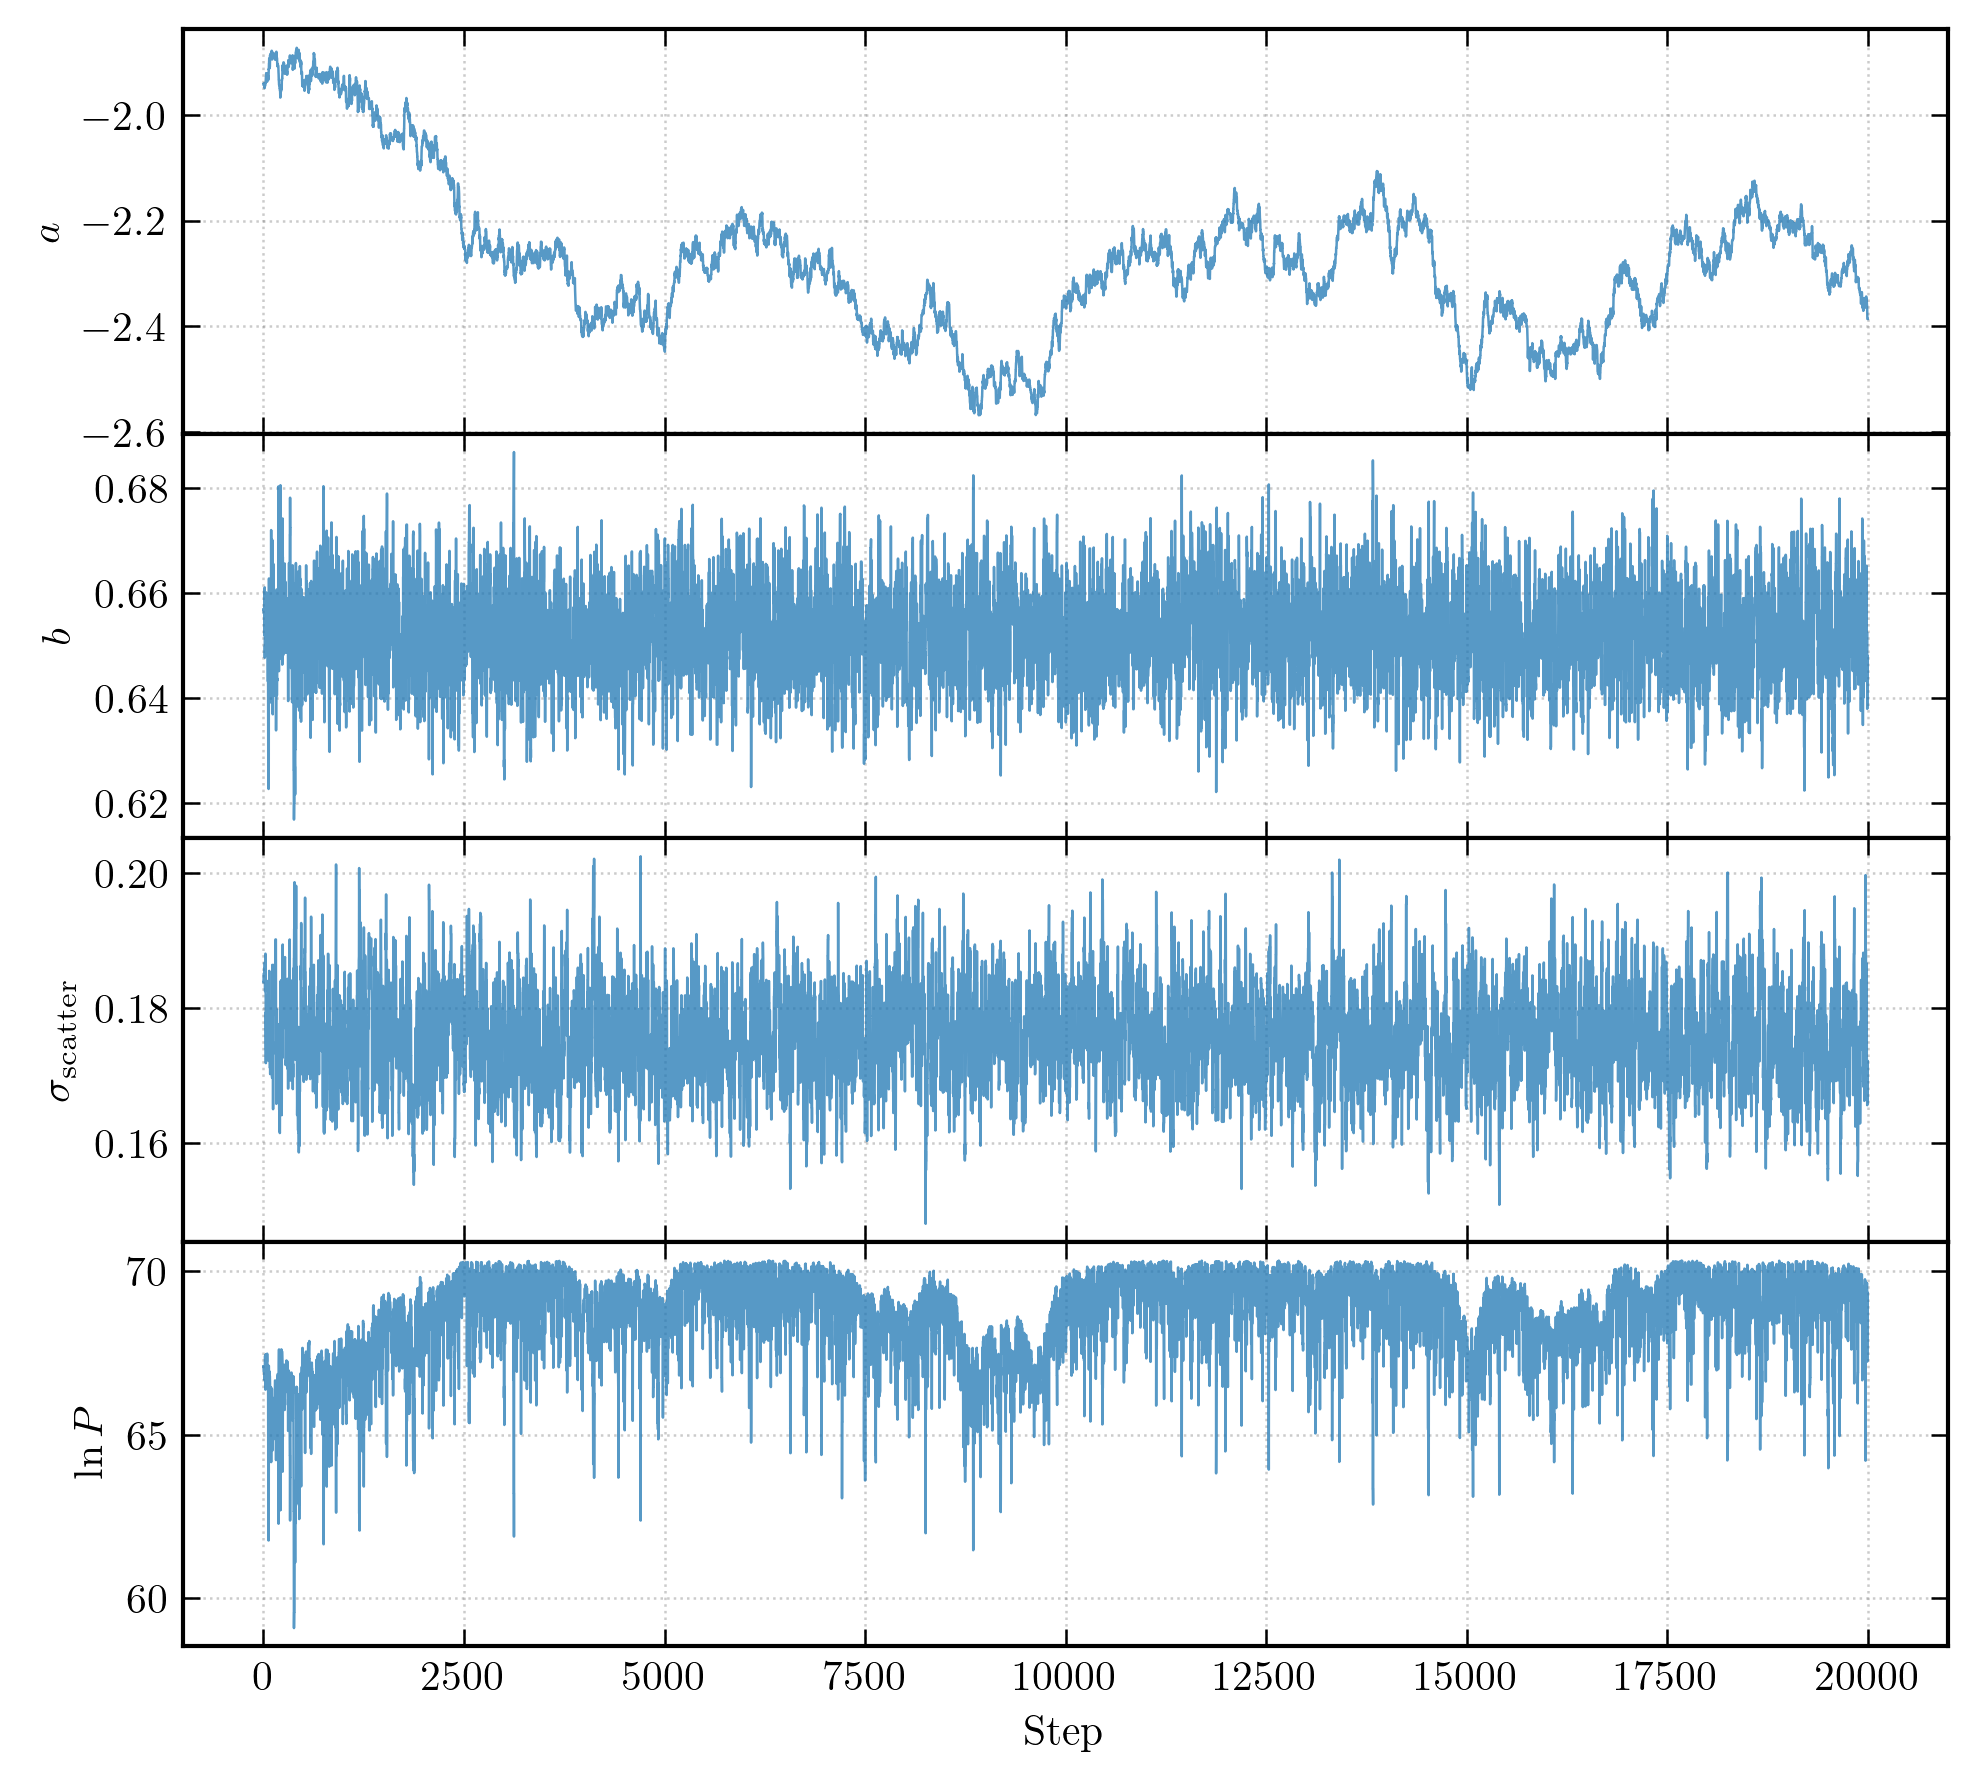

In [5]:
rrab_mh = run_mh_sampler(rrab_ctx, rrab_proposal_std)

axes = plot_trace(rrab_mh)
plt.show()

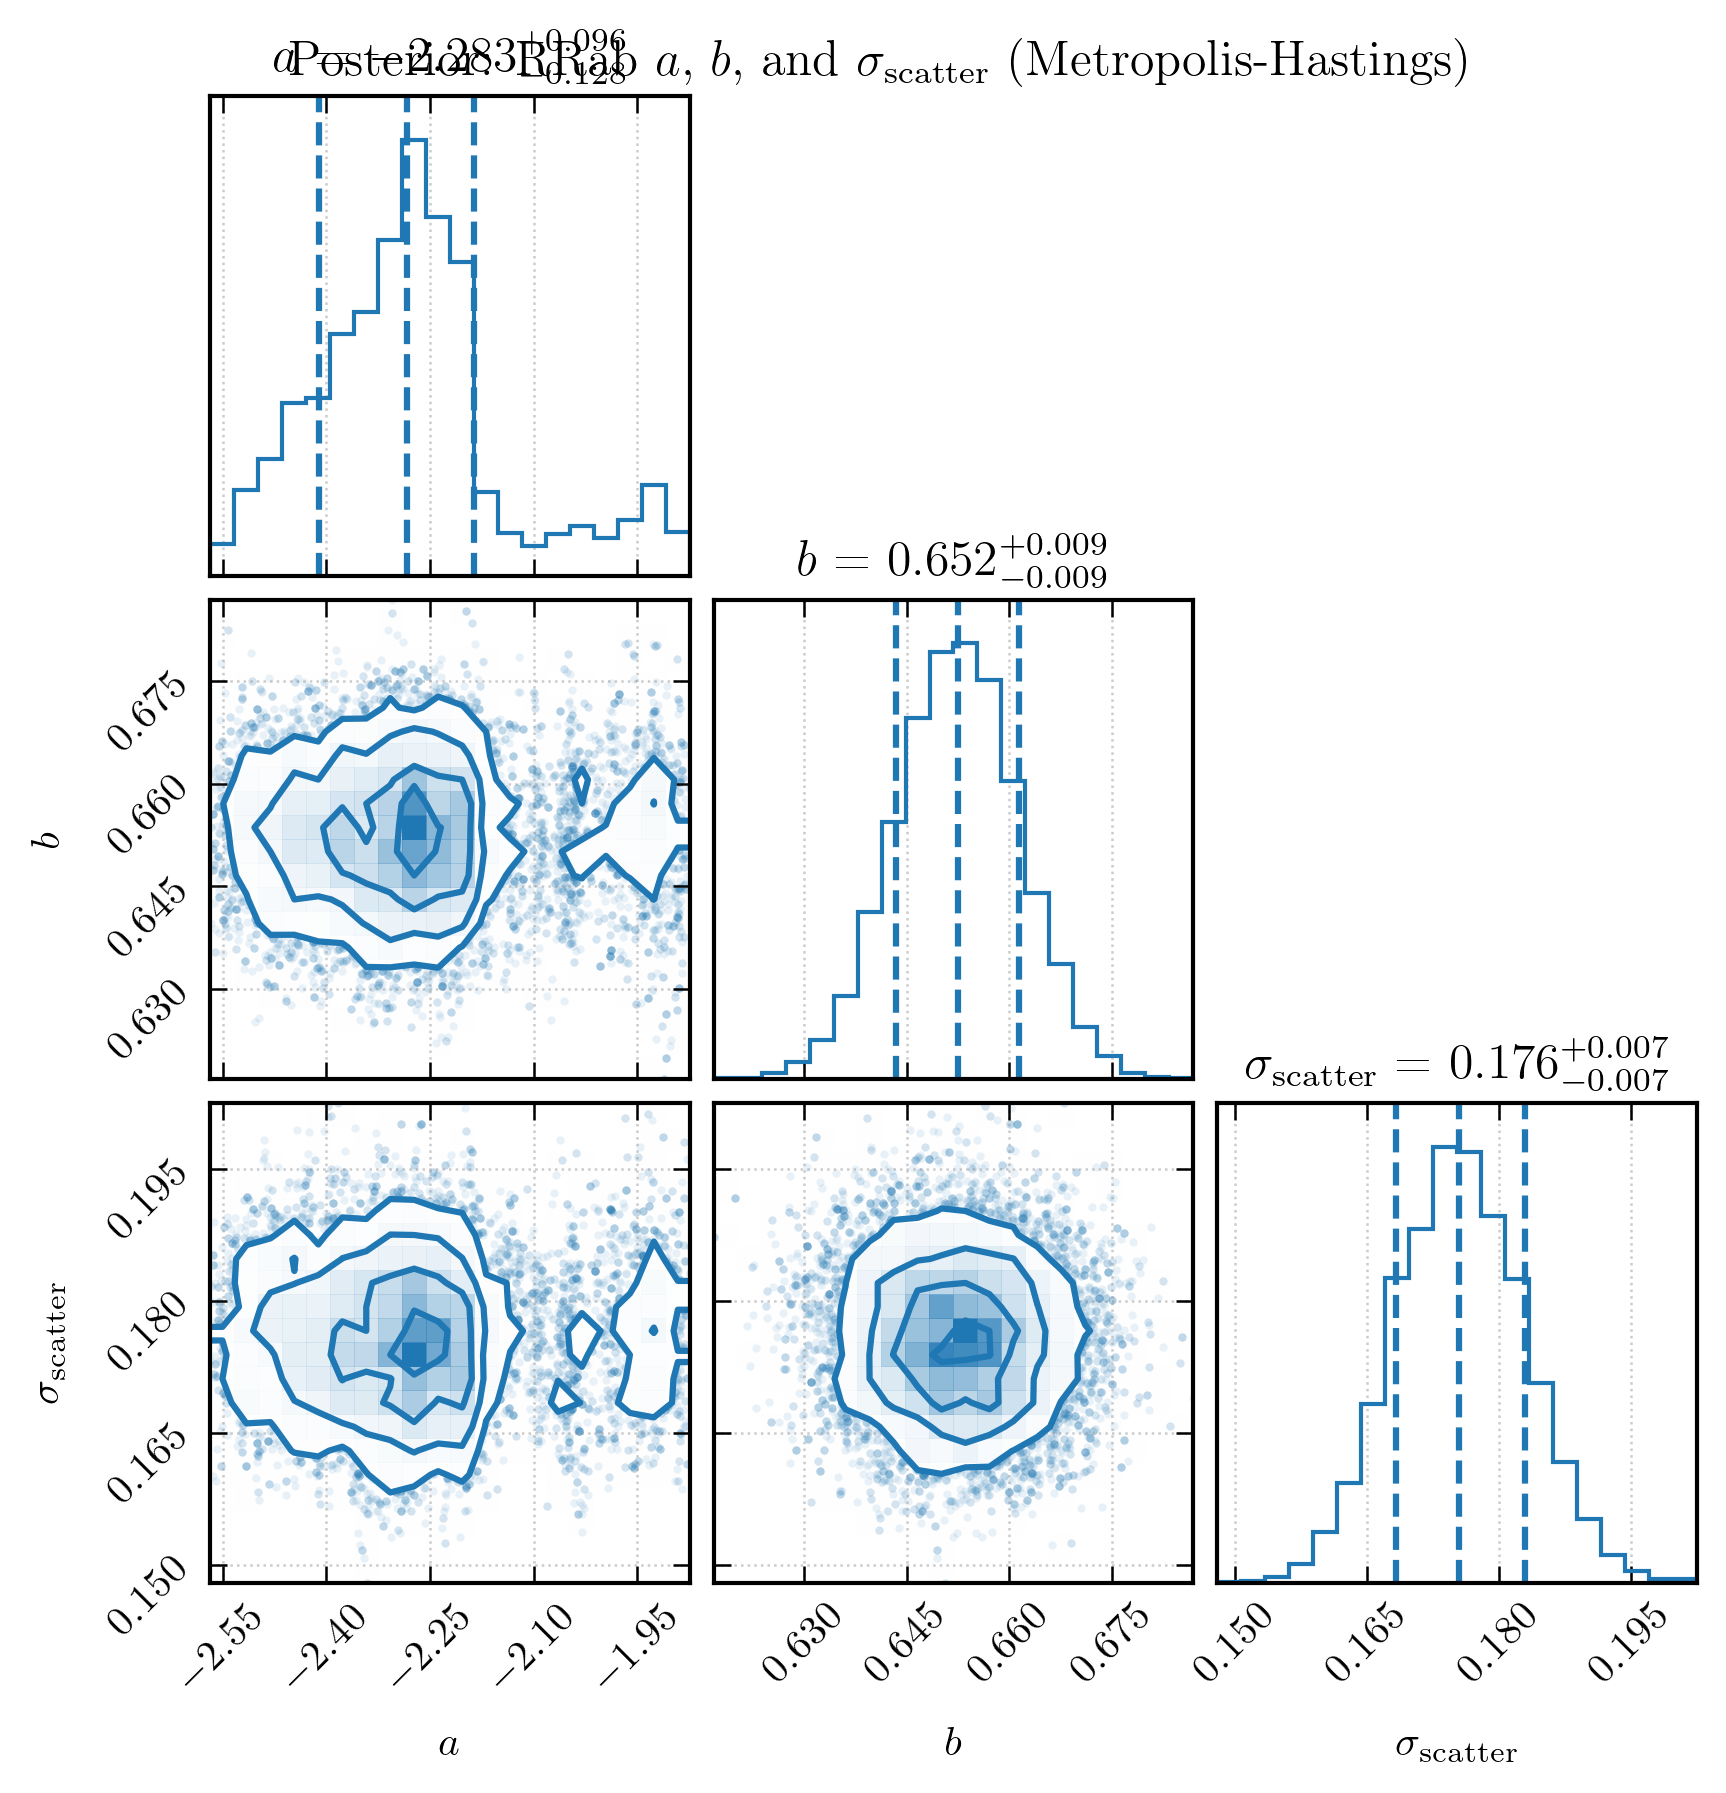

In [6]:
fig = plot_corner(rrab_mh)
fig.suptitle(r"Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (Metropolis-Hastings)")
_savefig(fig, "fig_mh_corner.pdf")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


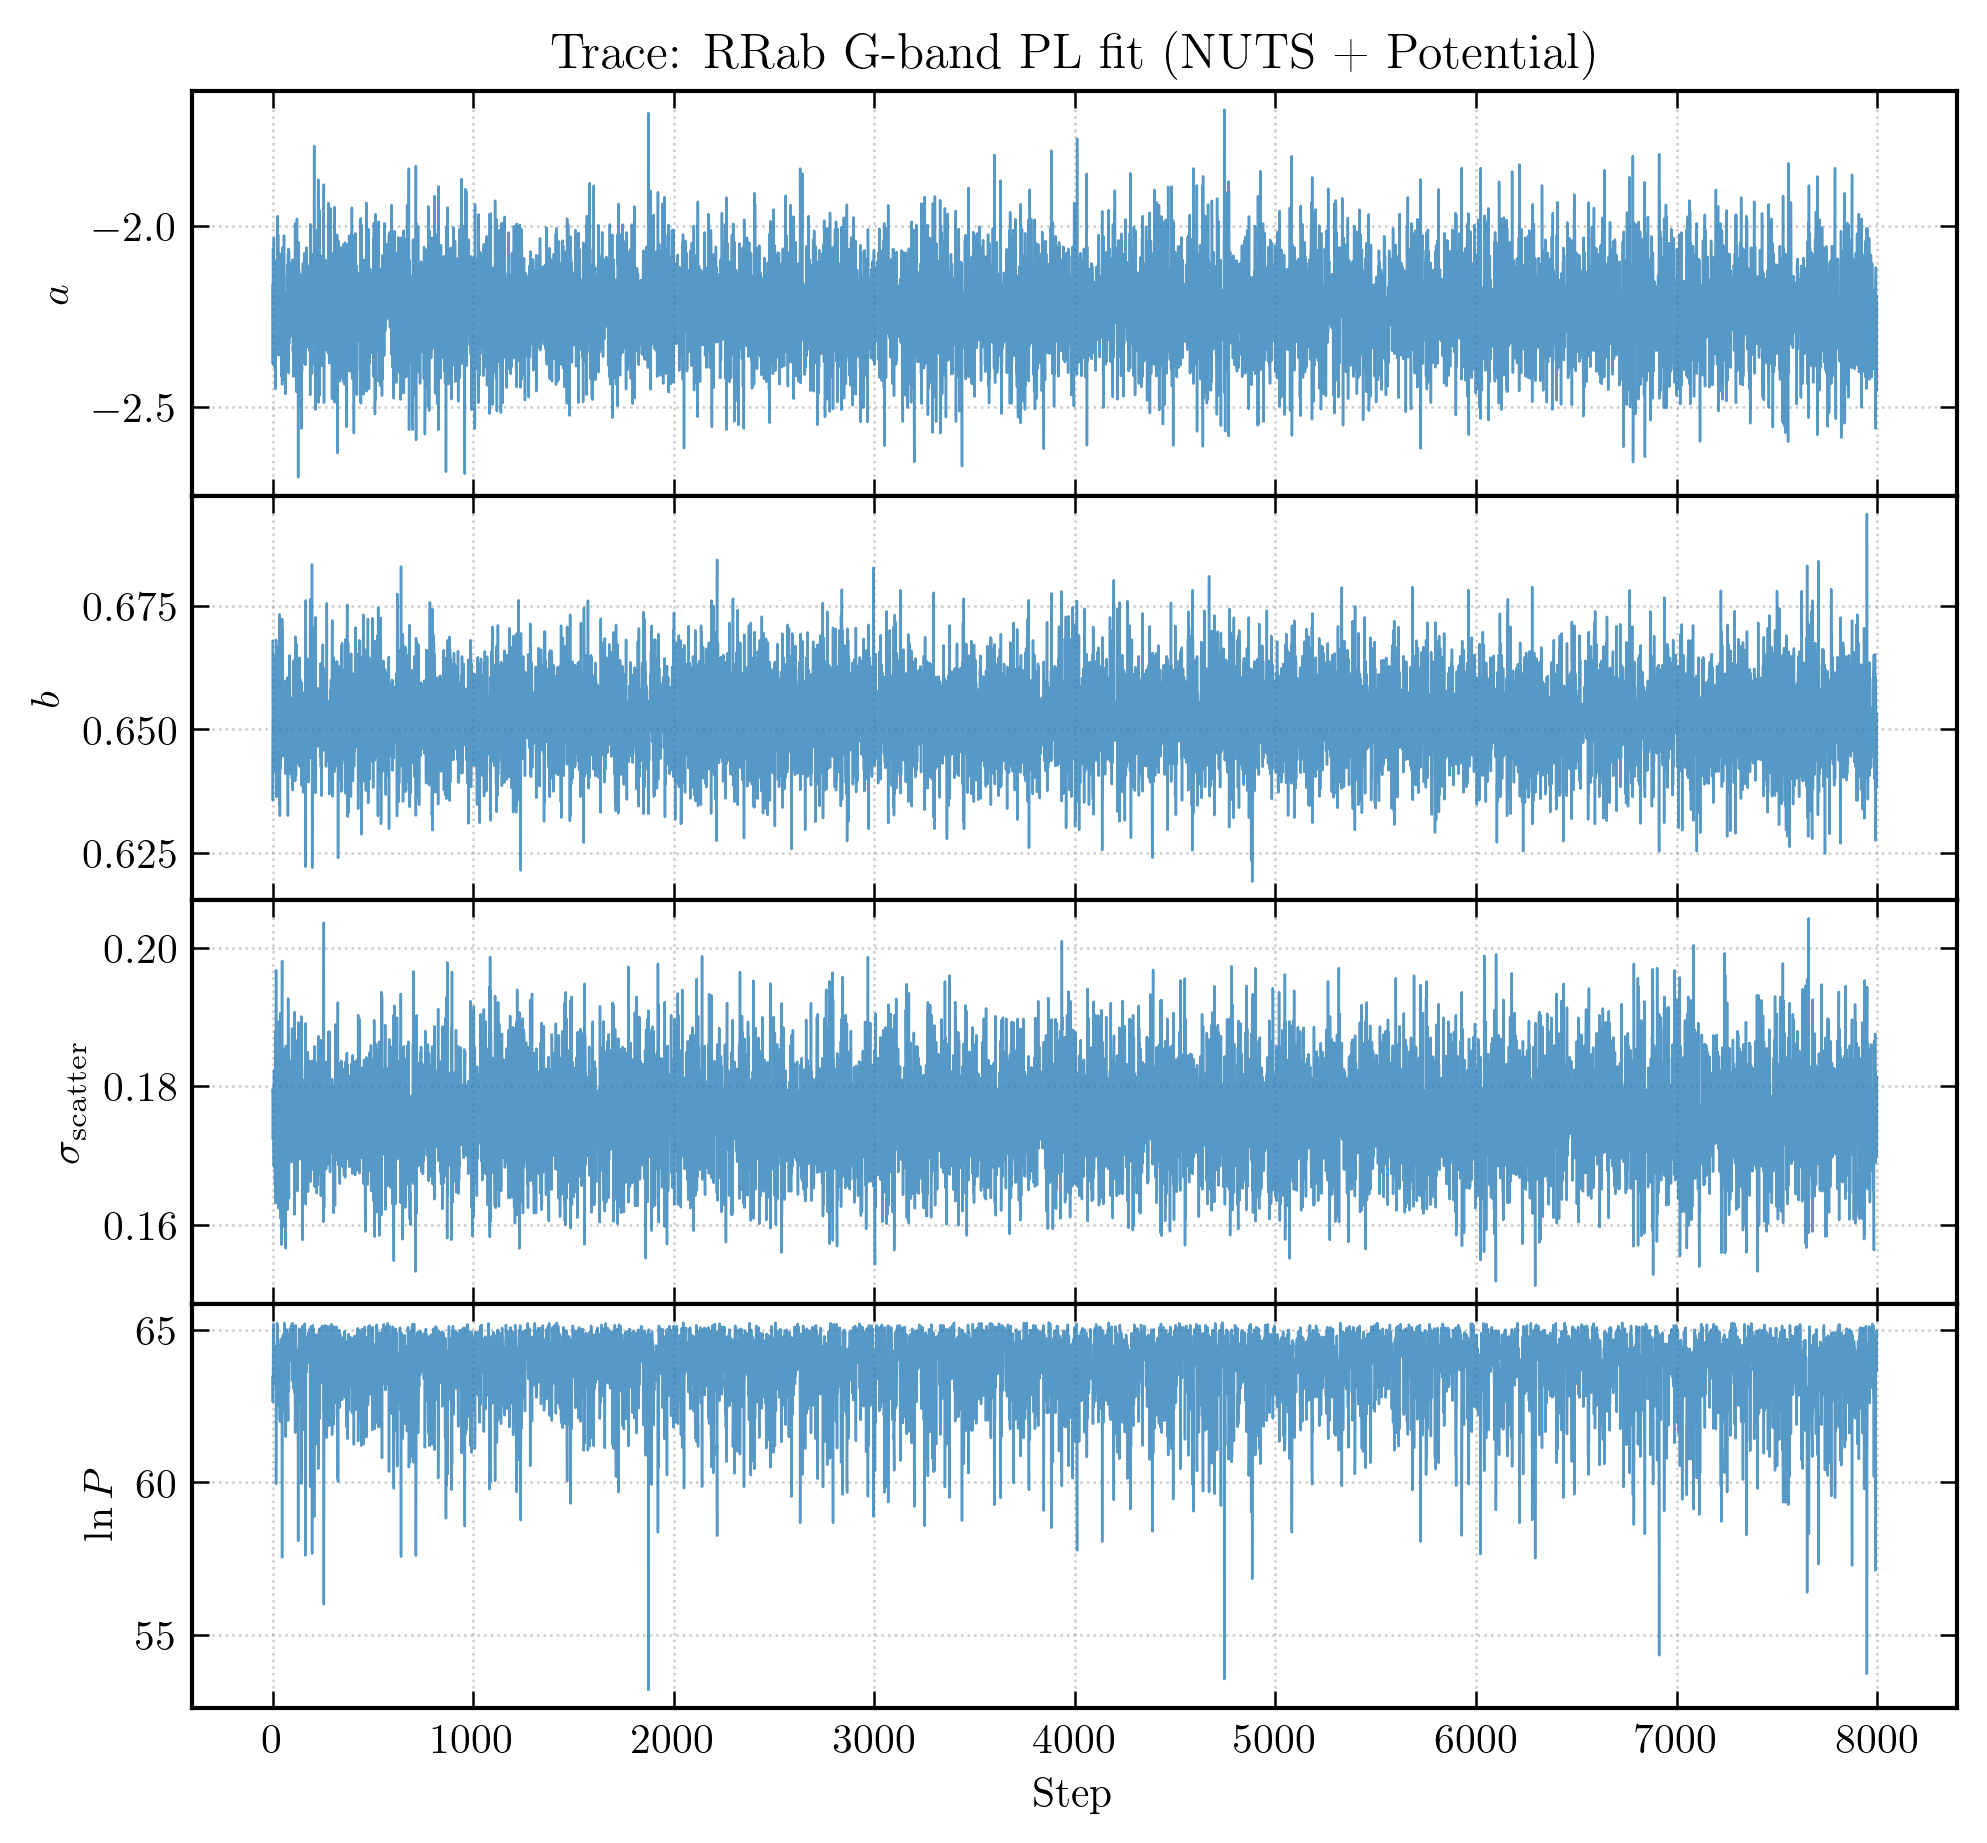

In [7]:
rrab_nuts_potential = fit_nuts_potential(rrab_ctx)

axes = plot_trace(to_display(rrab_nuts_potential))
axes[0].set_title("Trace: RRab G-band PL fit (NUTS + Potential)")
plt.show()

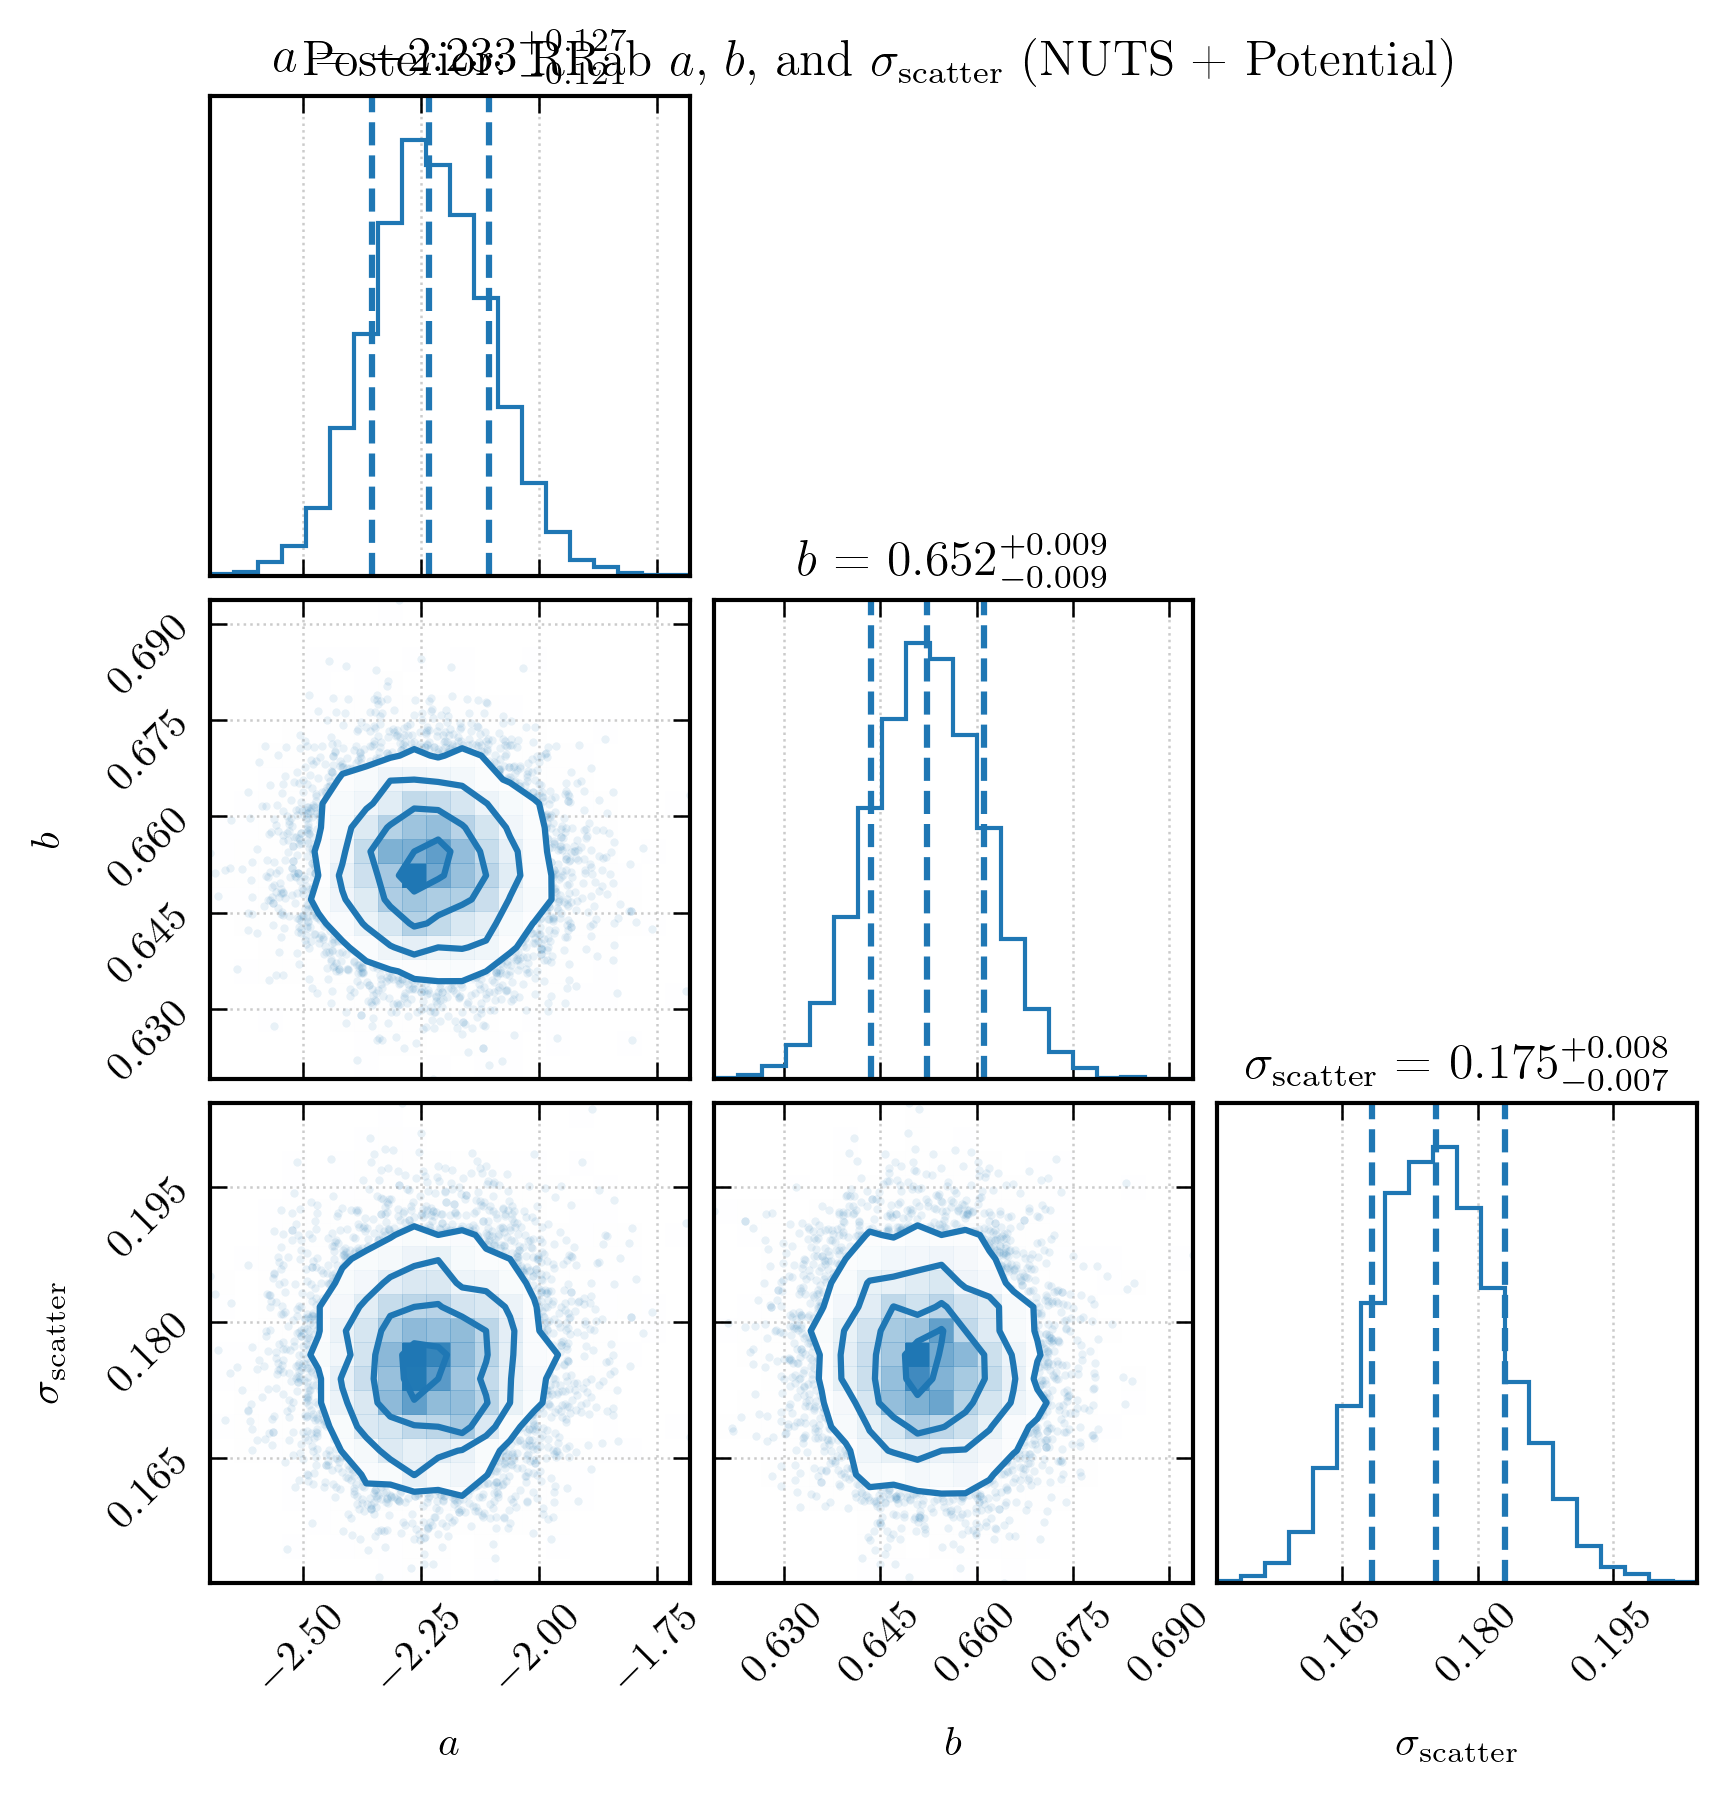

In [8]:
fig = plot_corner(to_display(rrab_nuts_potential))
fig.suptitle(r"Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (NUTS + Potential)")
_savefig(fig, "fig_nuts_corner.pdf")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


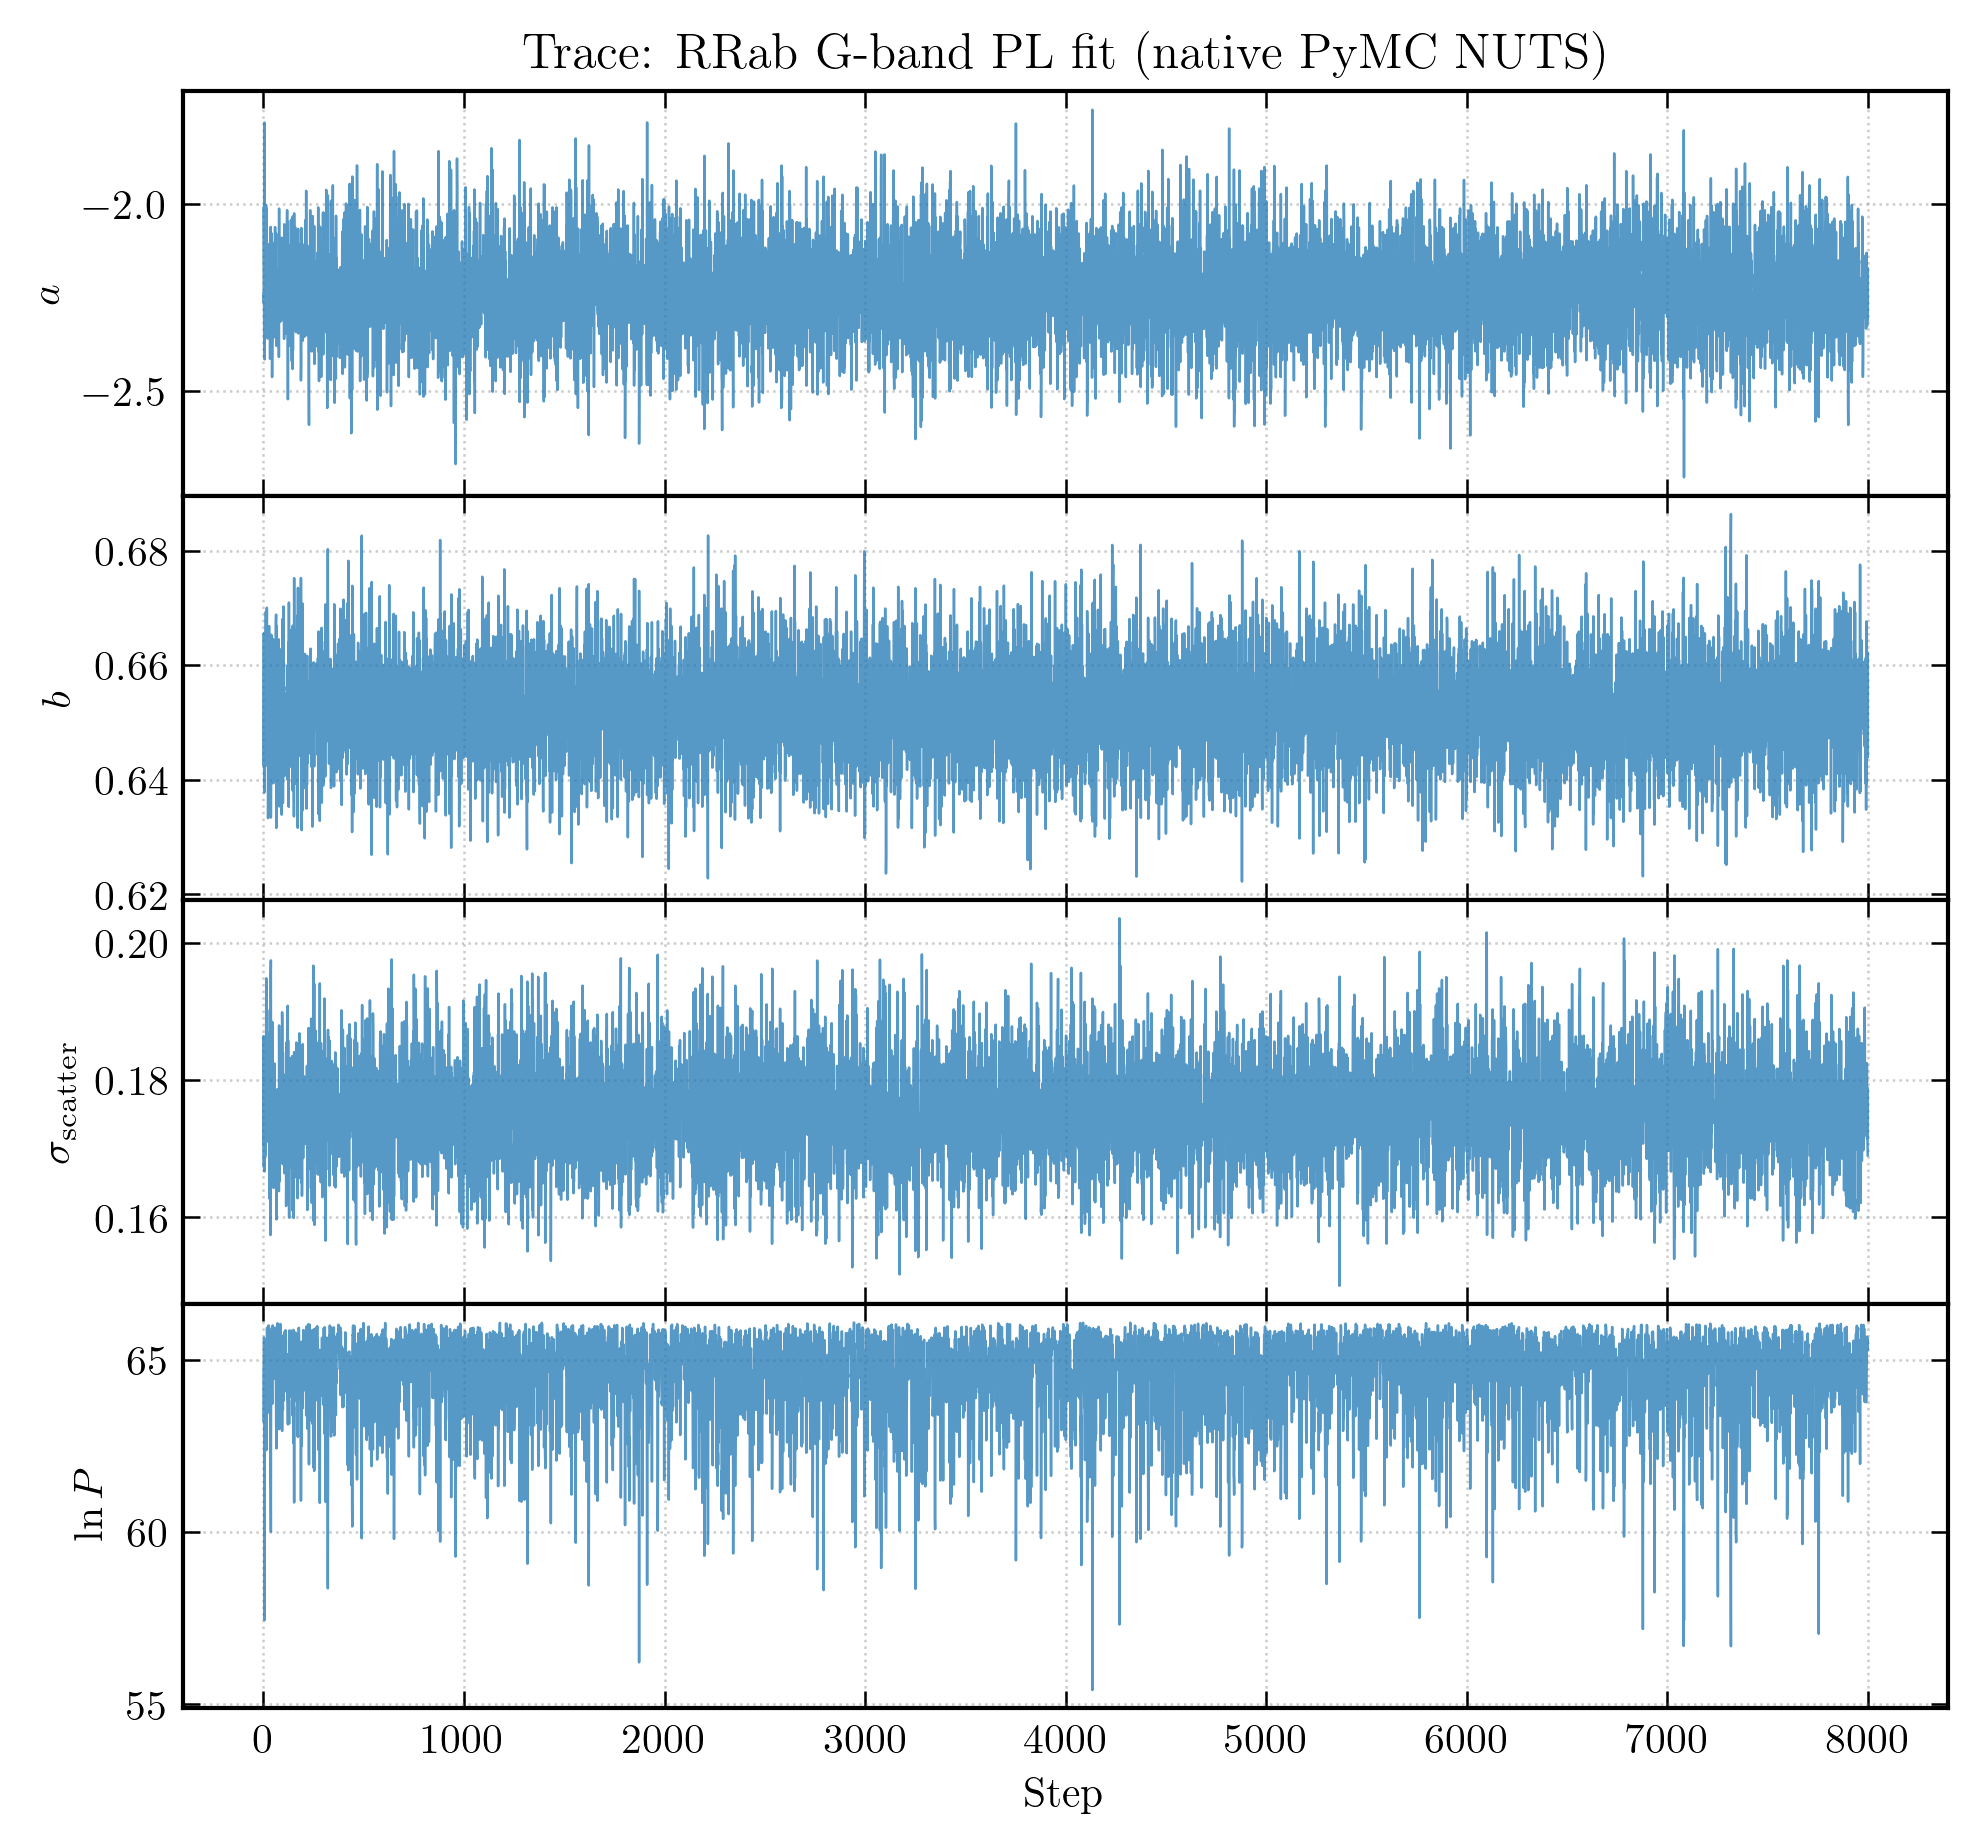

In [9]:
rrab_nuts_native = fit_nuts_native(rrab_ctx)

axes = plot_trace(to_display(rrab_nuts_native))
axes[0].set_title("Trace: RRab G-band PL fit (native PyMC NUTS)")
plt.show()

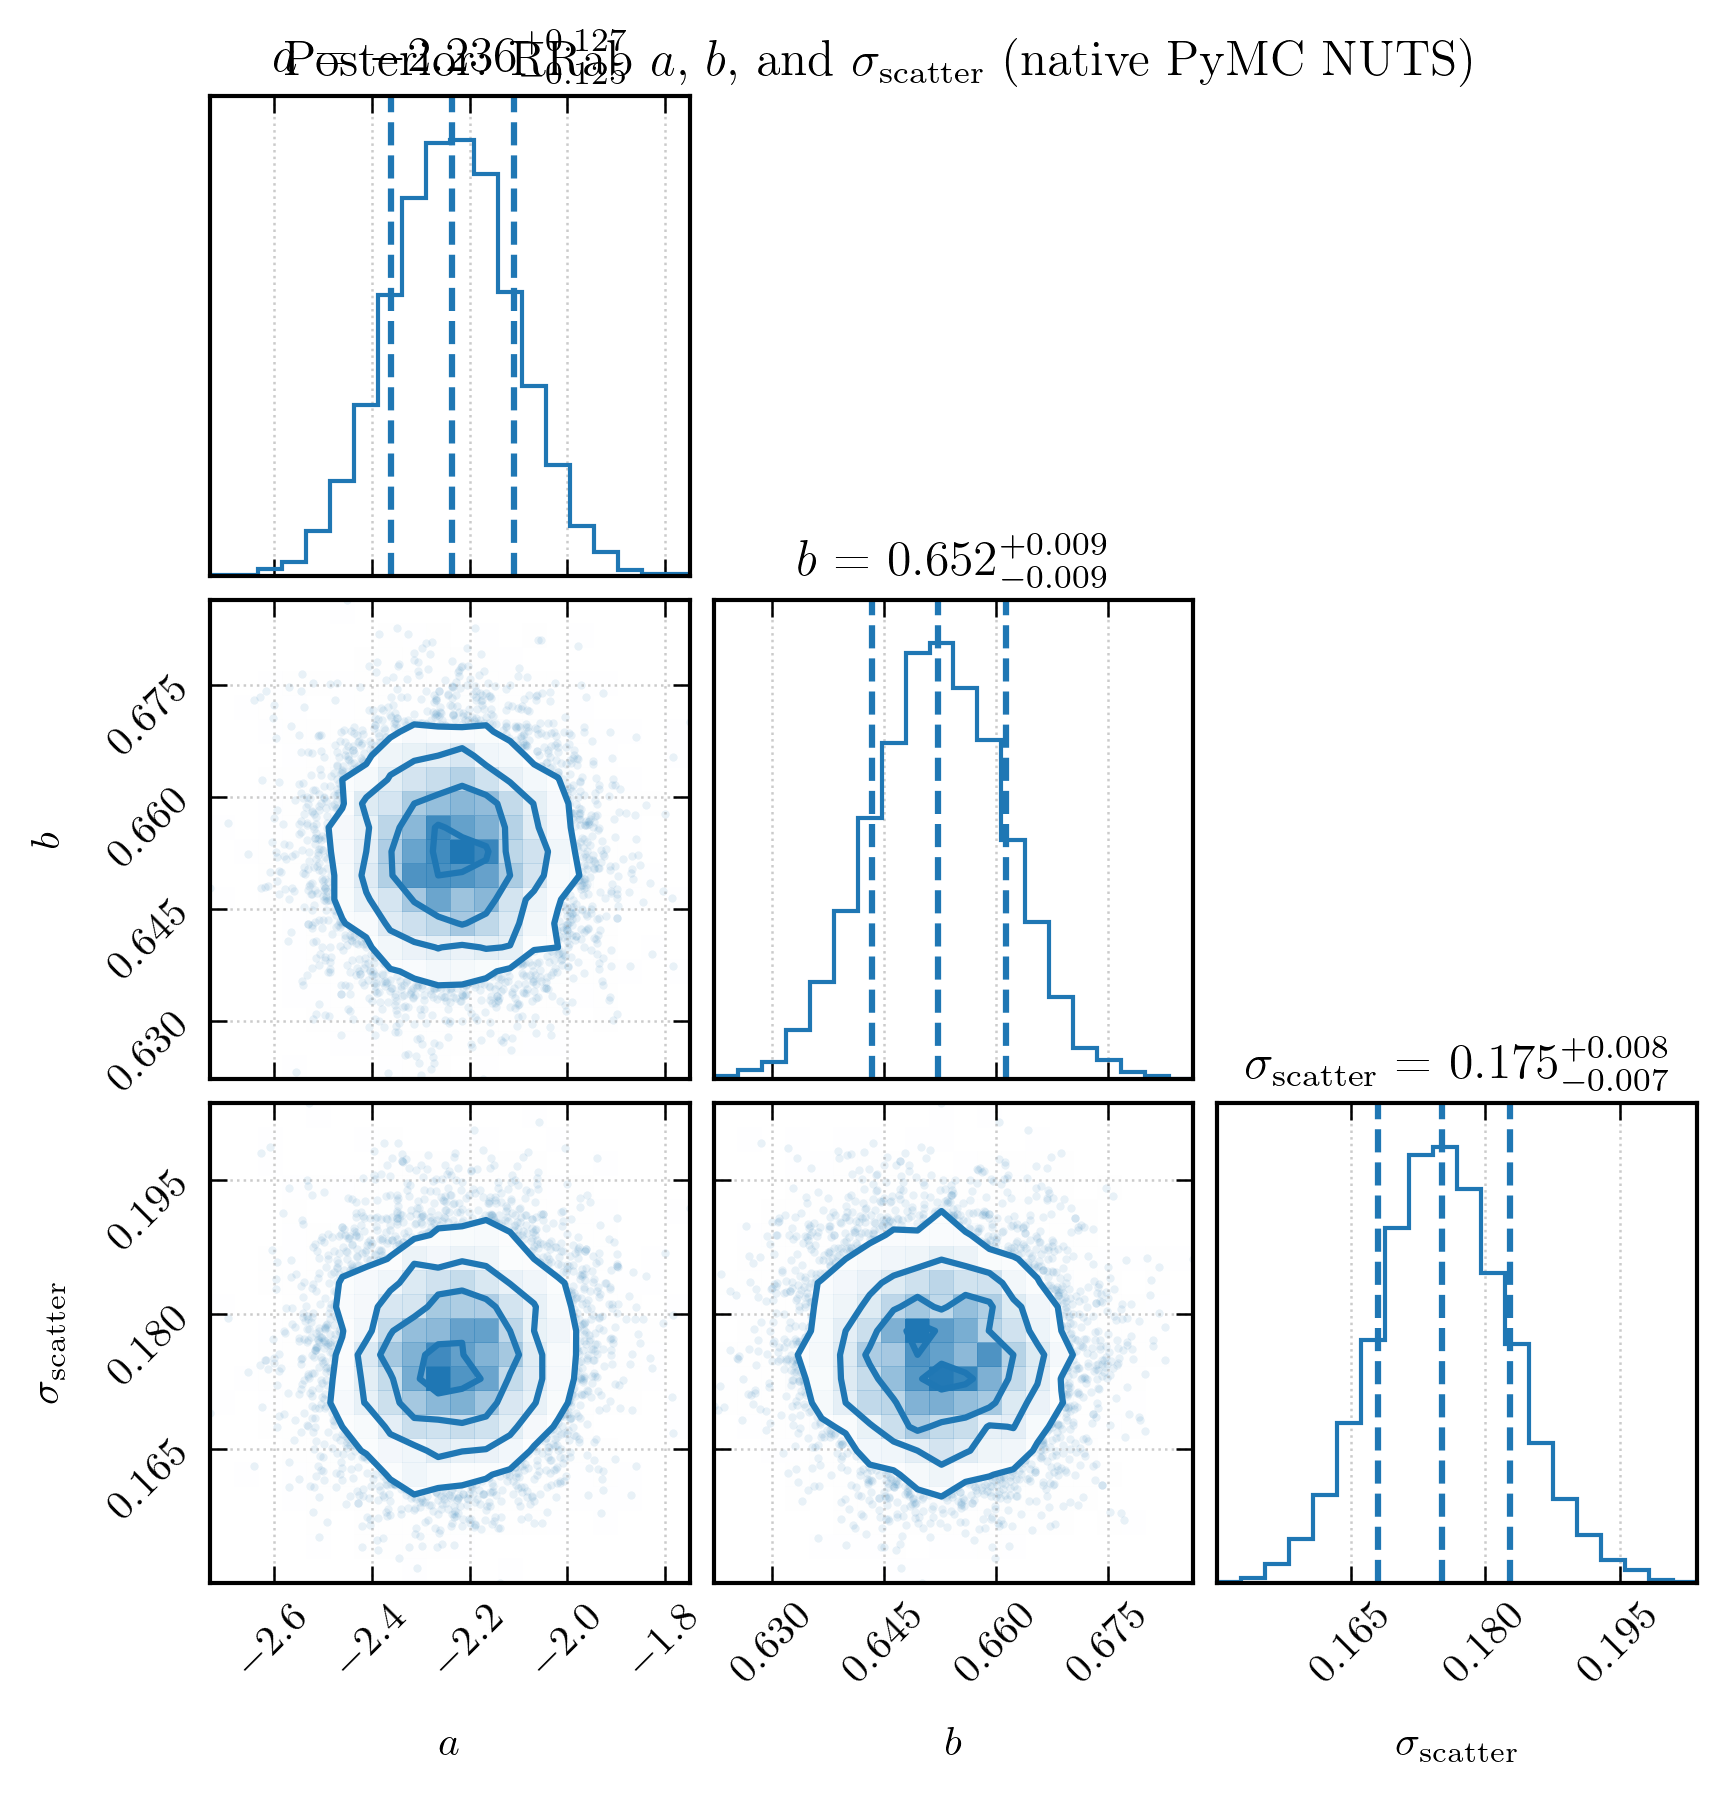

In [10]:
fig = plot_corner(to_display(rrab_nuts_native))
fig.suptitle(r"Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (native PyMC NUTS)")
_savefig(fig, "fig_native_corner.pdf")
plt.show()

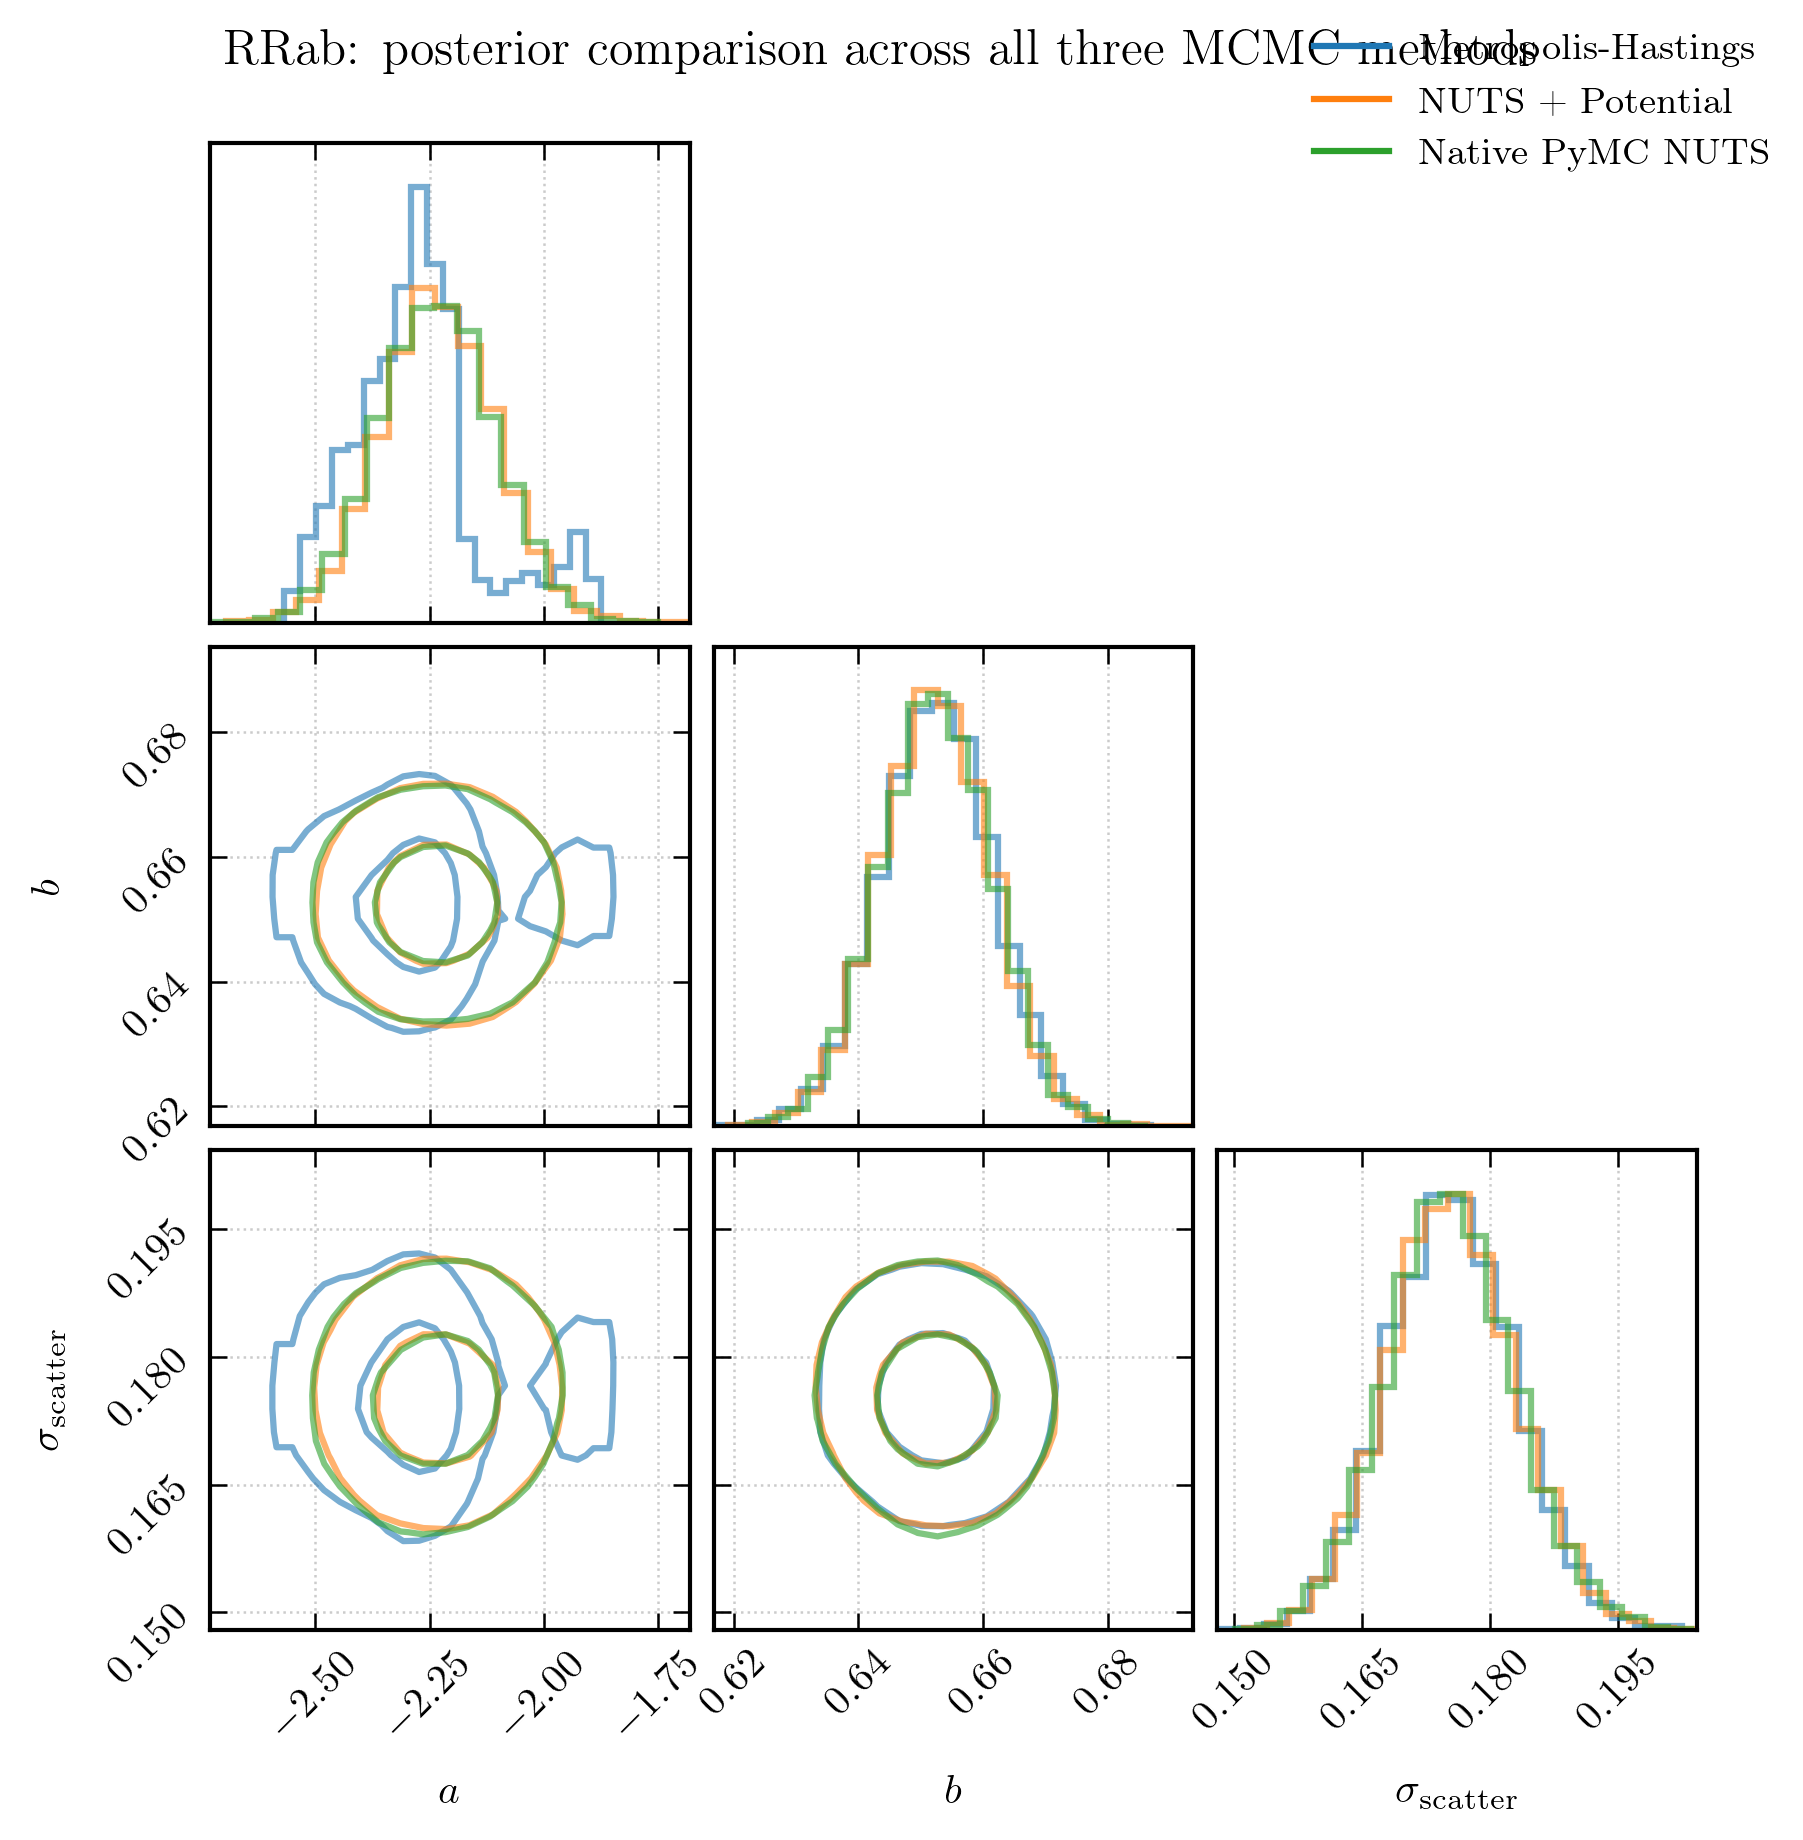

In [11]:
fig = plot_sampler_comparison_corner(
    {
        "Metropolis-Hastings": rrab_mh,
        "NUTS + Potential": to_display(rrab_nuts_potential),
        "Native PyMC NUTS": to_display(rrab_nuts_native),
    },
)
fig.suptitle(r"RRab: posterior comparison across all three MCMC methods", y=1.01)
_savefig(fig, "fig_methods_corner_rrab.pdf")
plt.show()

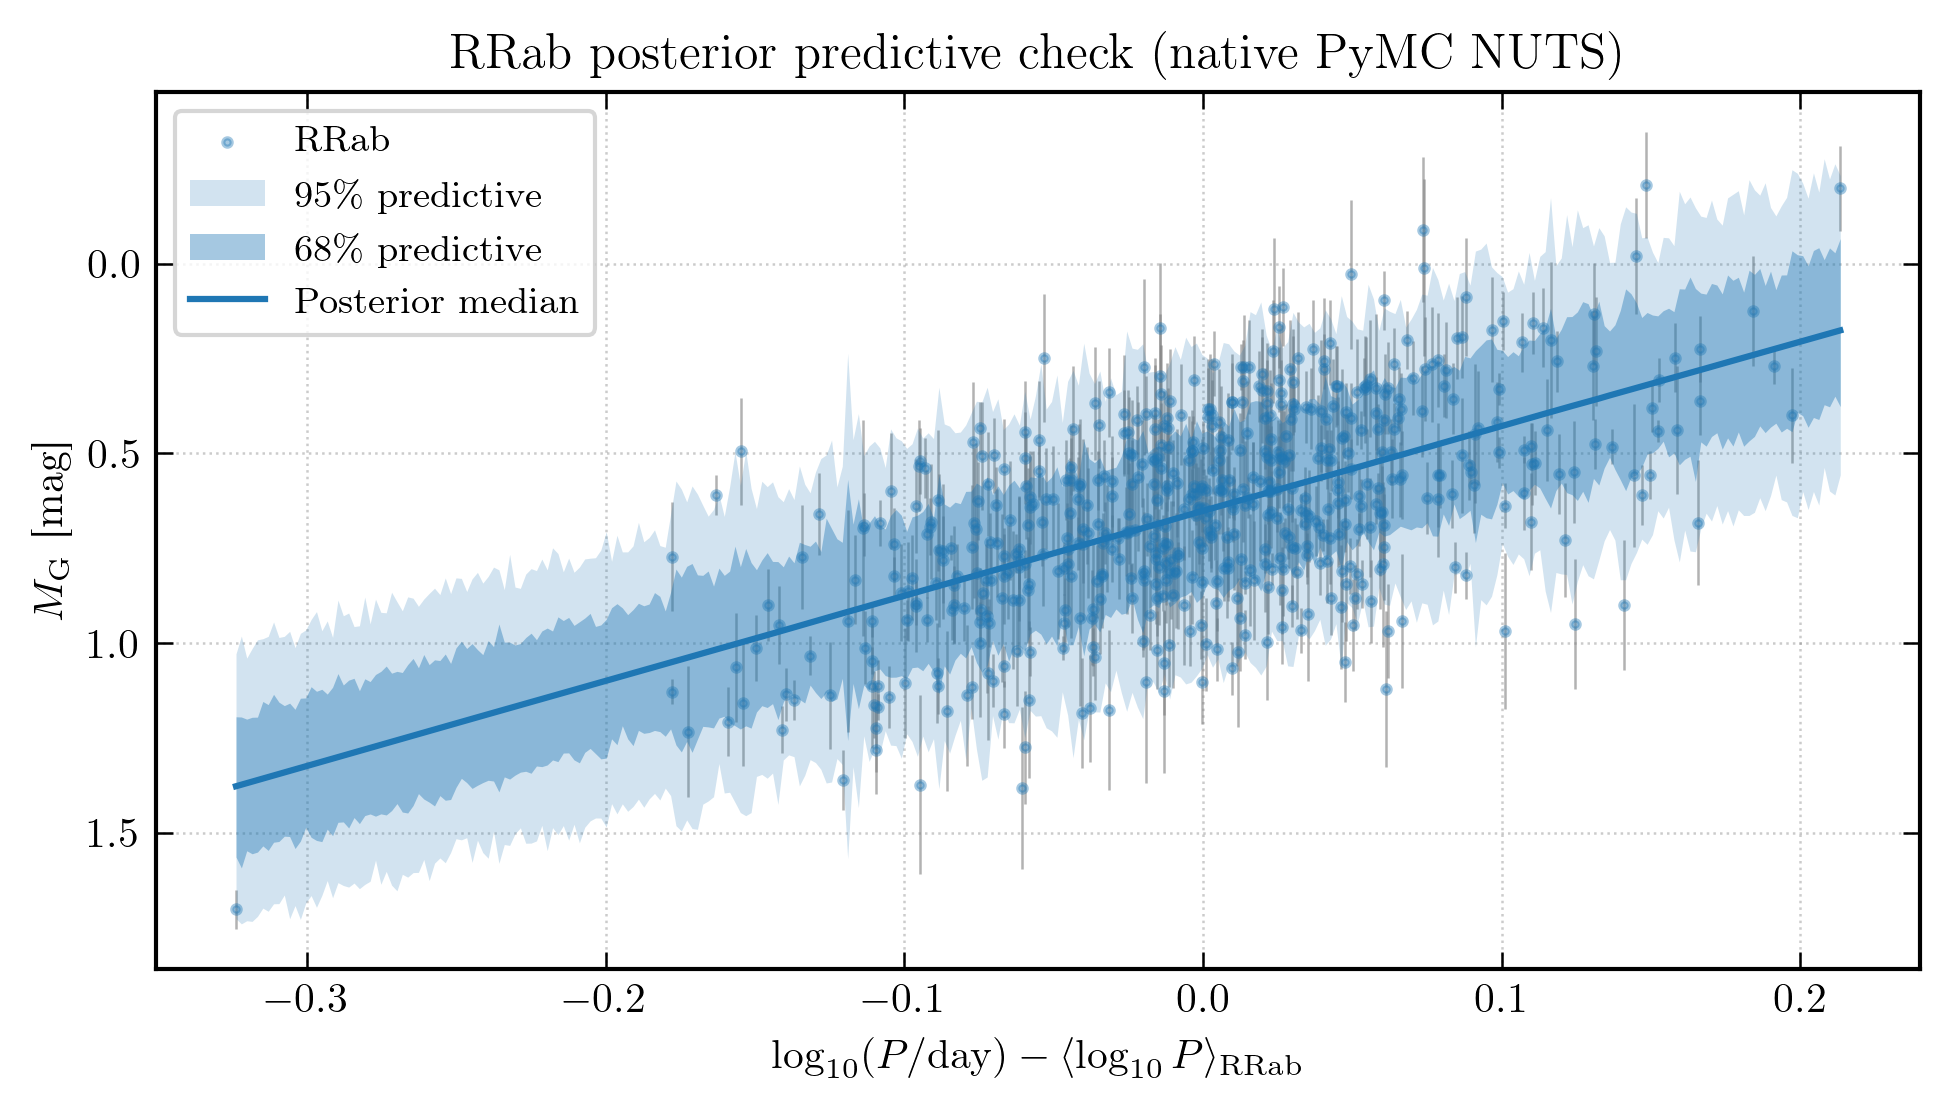

In [12]:
ax = plot_posterior_predictive(rrab_nuts_native, color="C0", data_label="RRab")
ax.set_xlabel(r"$\log_{10}(P/\mathrm{day}) - \langle \log_{10}P \rangle_{\rm RRab}$")
ax.set_ylabel(r"$M_{\rm G}$ [mag]")
ax.set_title("RRab posterior predictive check (native PyMC NUTS)")
_savefig(ax.figure, "fig_pl_posterior.pdf")
plt.show()

In [13]:
rrc_proposal_scan = []
for s_a, s_b, s_sig in product(*MH_PROPOSAL_AXES):
    ps = np.array([s_a, s_b, s_sig])
    result = run_mh_sampler(rrc_ctx, ps, n_steps=4_000, n_burn=500)
    rrc_proposal_scan.append({
        "s_a": s_a, "s_b": s_b, "s_sig": s_sig,
        "acceptance": round(result.acceptance_rate, 3),
    })
rrc_proposal_scan = pd.DataFrame(rrc_proposal_scan)

best_row = rrc_proposal_scan.loc[(rrc_proposal_scan["acceptance"] - 0.5).abs().idxmin()]
rrc_proposal_std = np.array([best_row["s_a"], best_row["s_b"], best_row["s_sig"]])
rrc_proposal_scan

,s_a,s_b,s_sig,acceptance
0,0.004,0.008,0.008,0.734
1,0.004,0.008,0.012,0.694
2,0.004,0.008,0.016,0.654
3,0.004,0.008,0.020,0.622
4,0.004,0.012,0.008,0.657
...,...,...,...,...
59,0.010,0.016,0.020,0.497
60,0.010,0.020,0.008,0.509
61,0.010,0.020,0.012,0.484
62,0.010,0.020,0.016,0.466


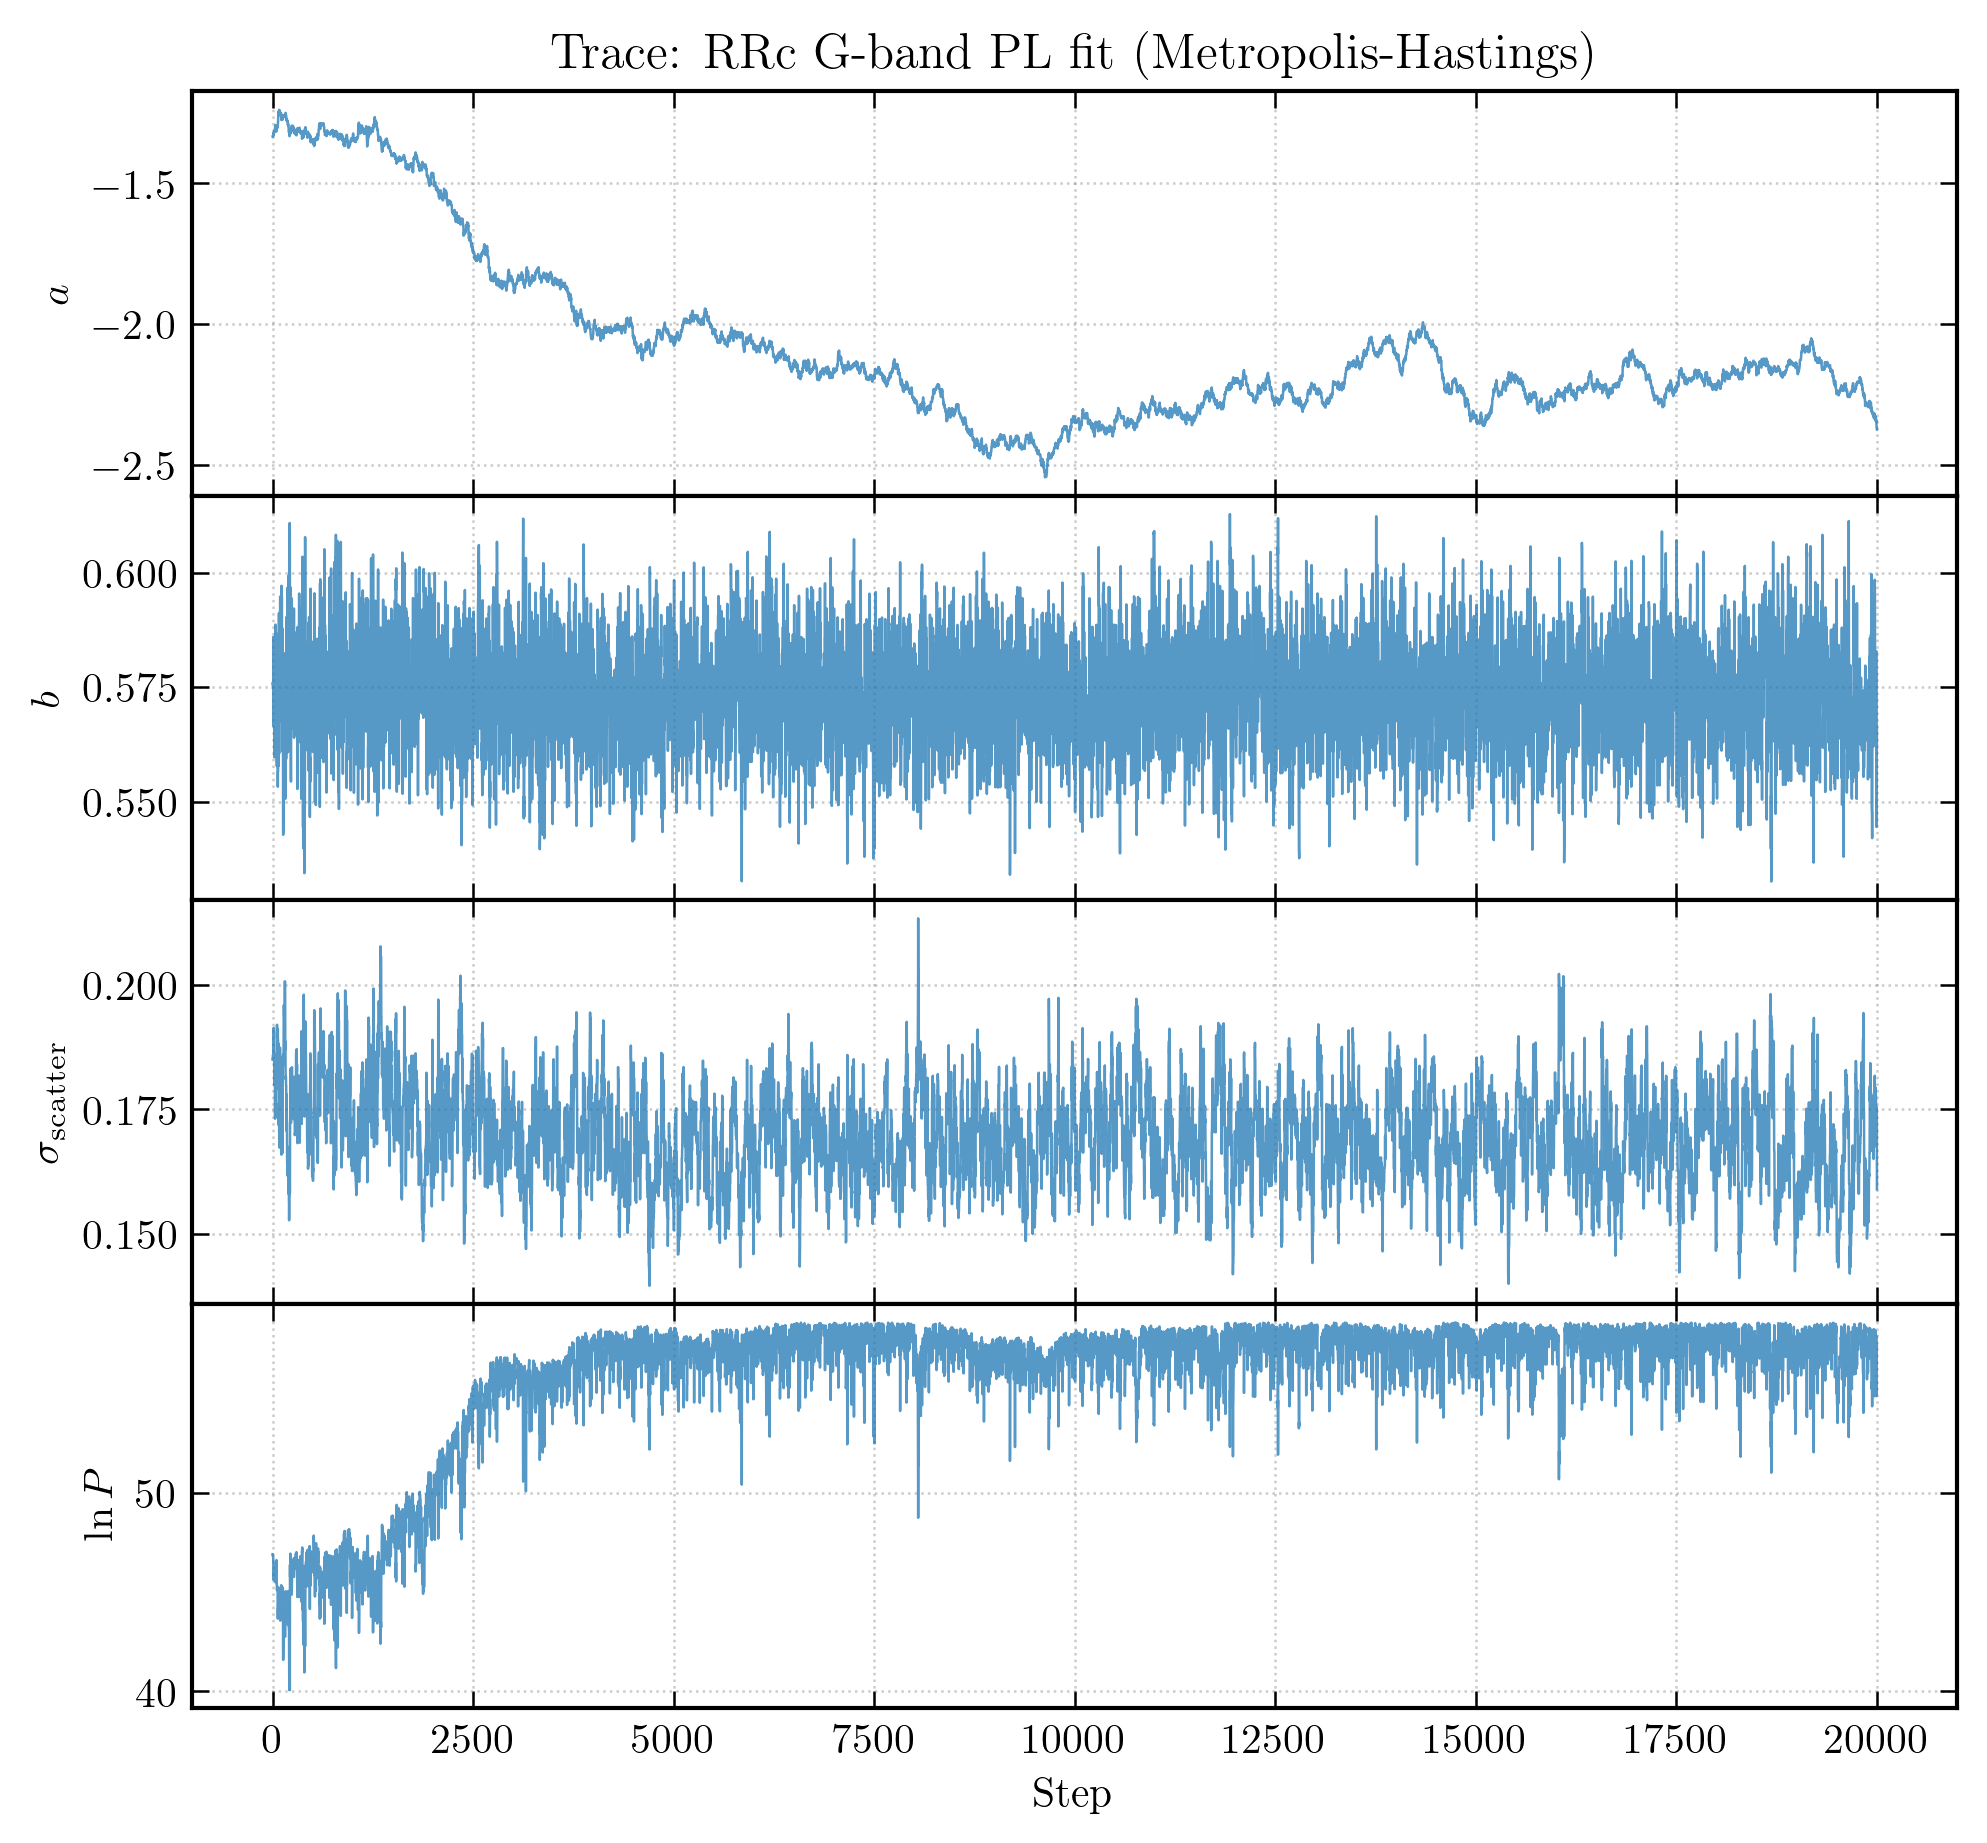

In [14]:
rrc_mh = run_mh_sampler(rrc_ctx, rrc_proposal_std)

axes = plot_trace(rrc_mh)
axes[0].set_title("Trace: RRc G-band PL fit (Metropolis-Hastings)")
plt.show()

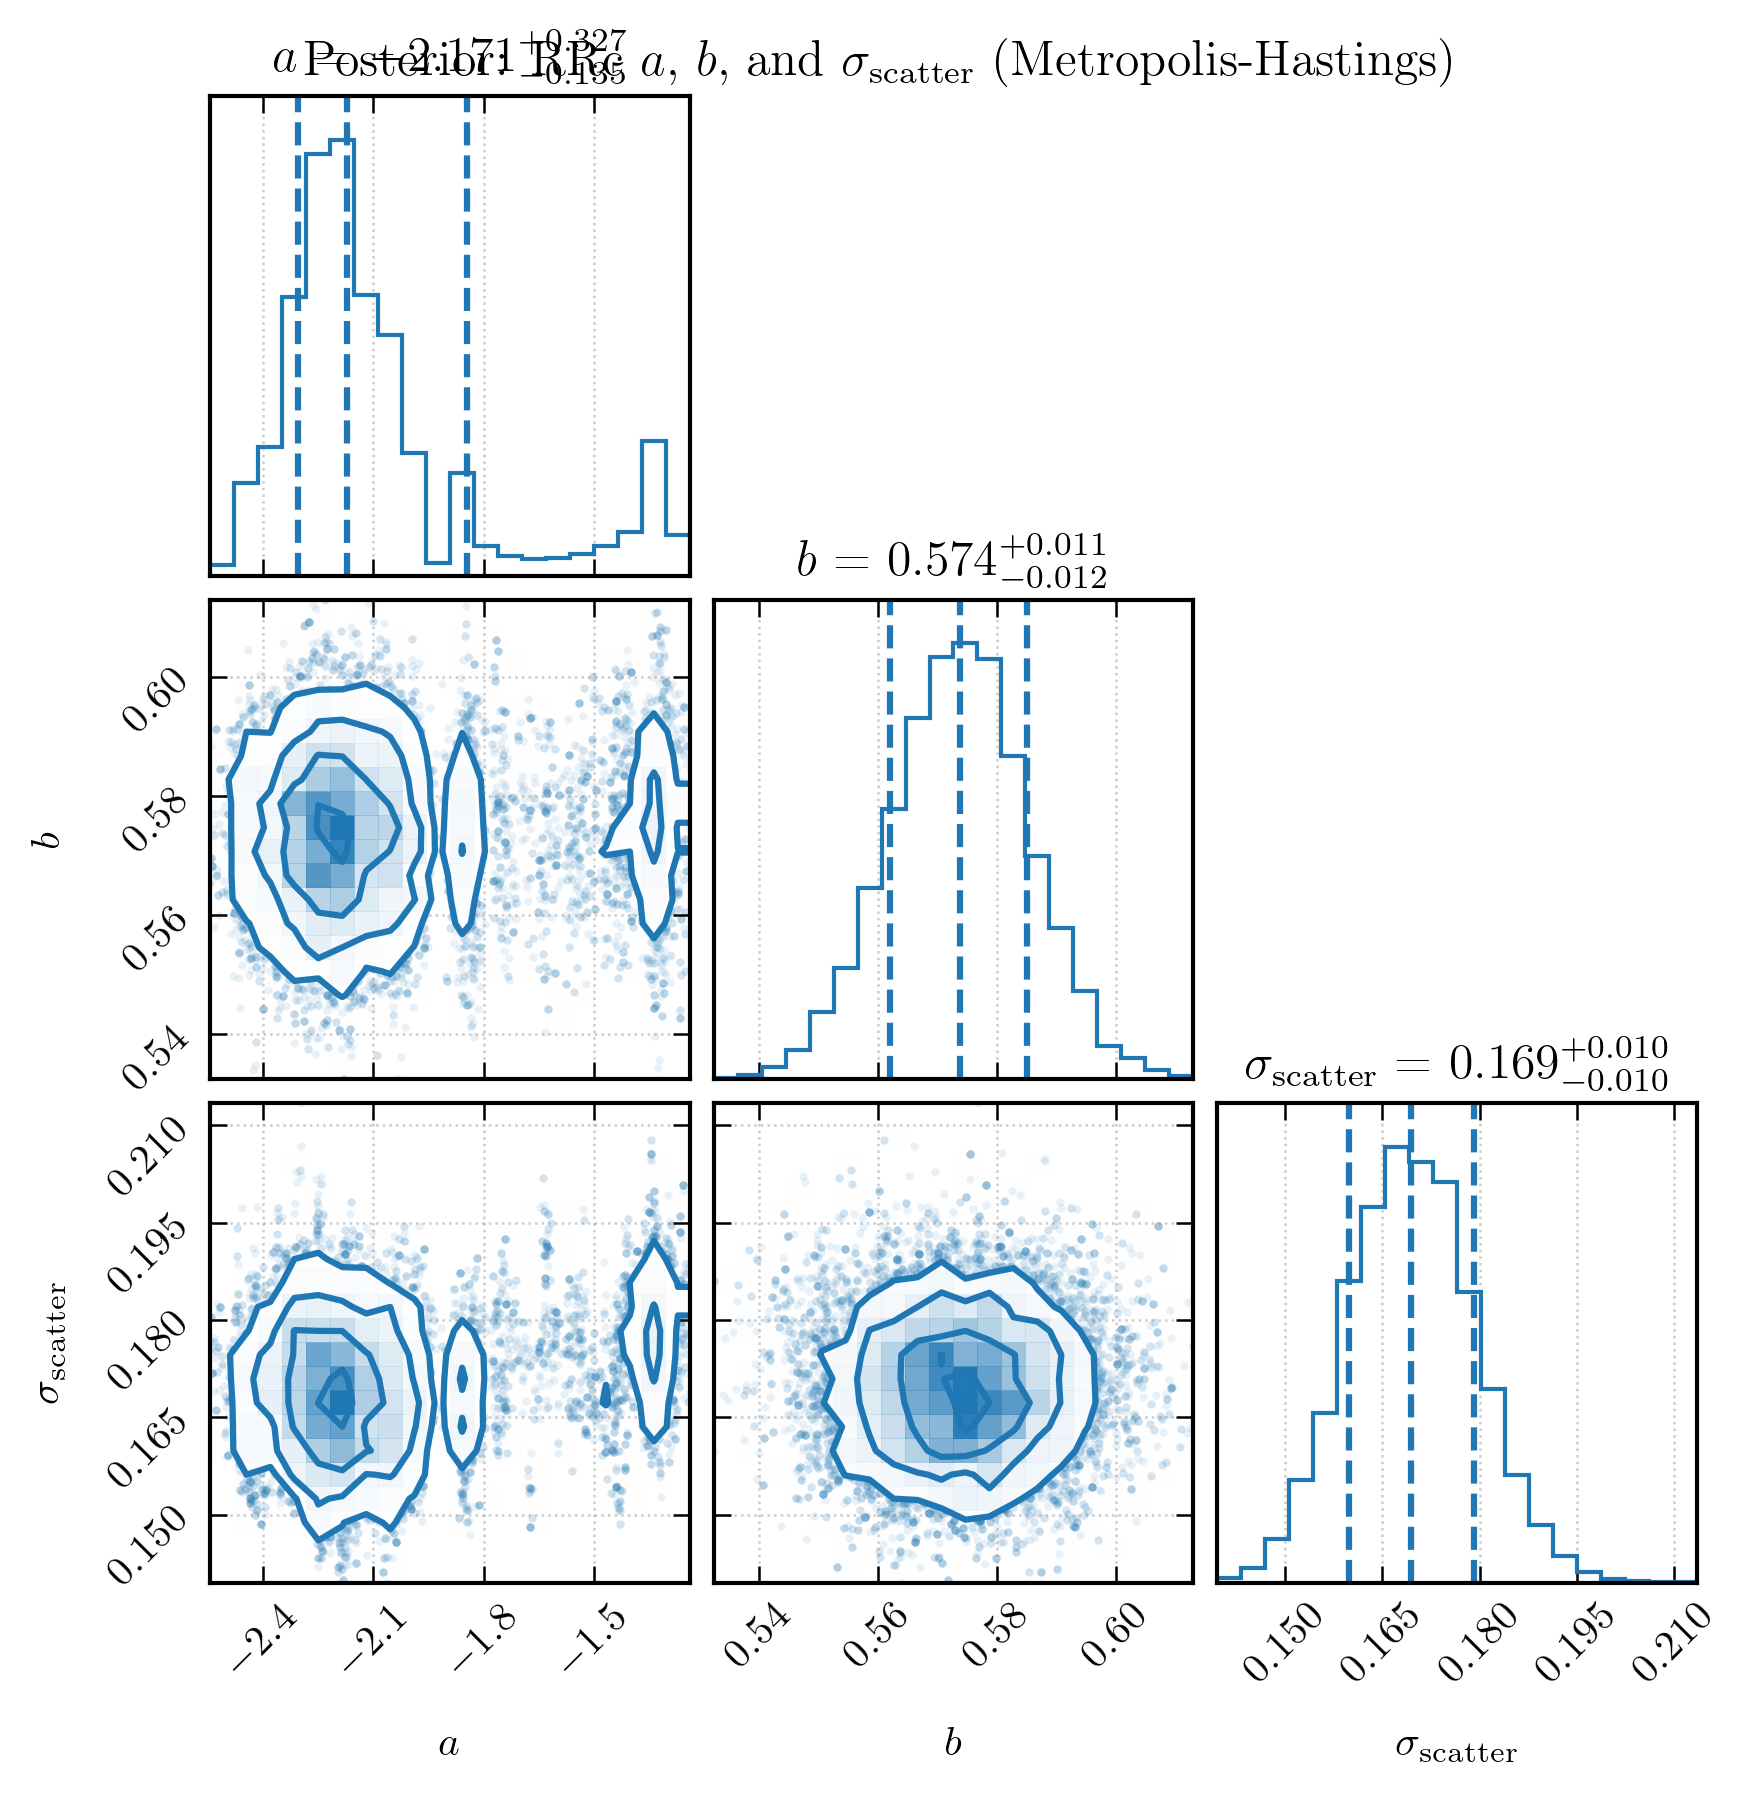

In [15]:
fig = plot_corner(rrc_mh)
fig.suptitle(r"Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (Metropolis-Hastings)")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


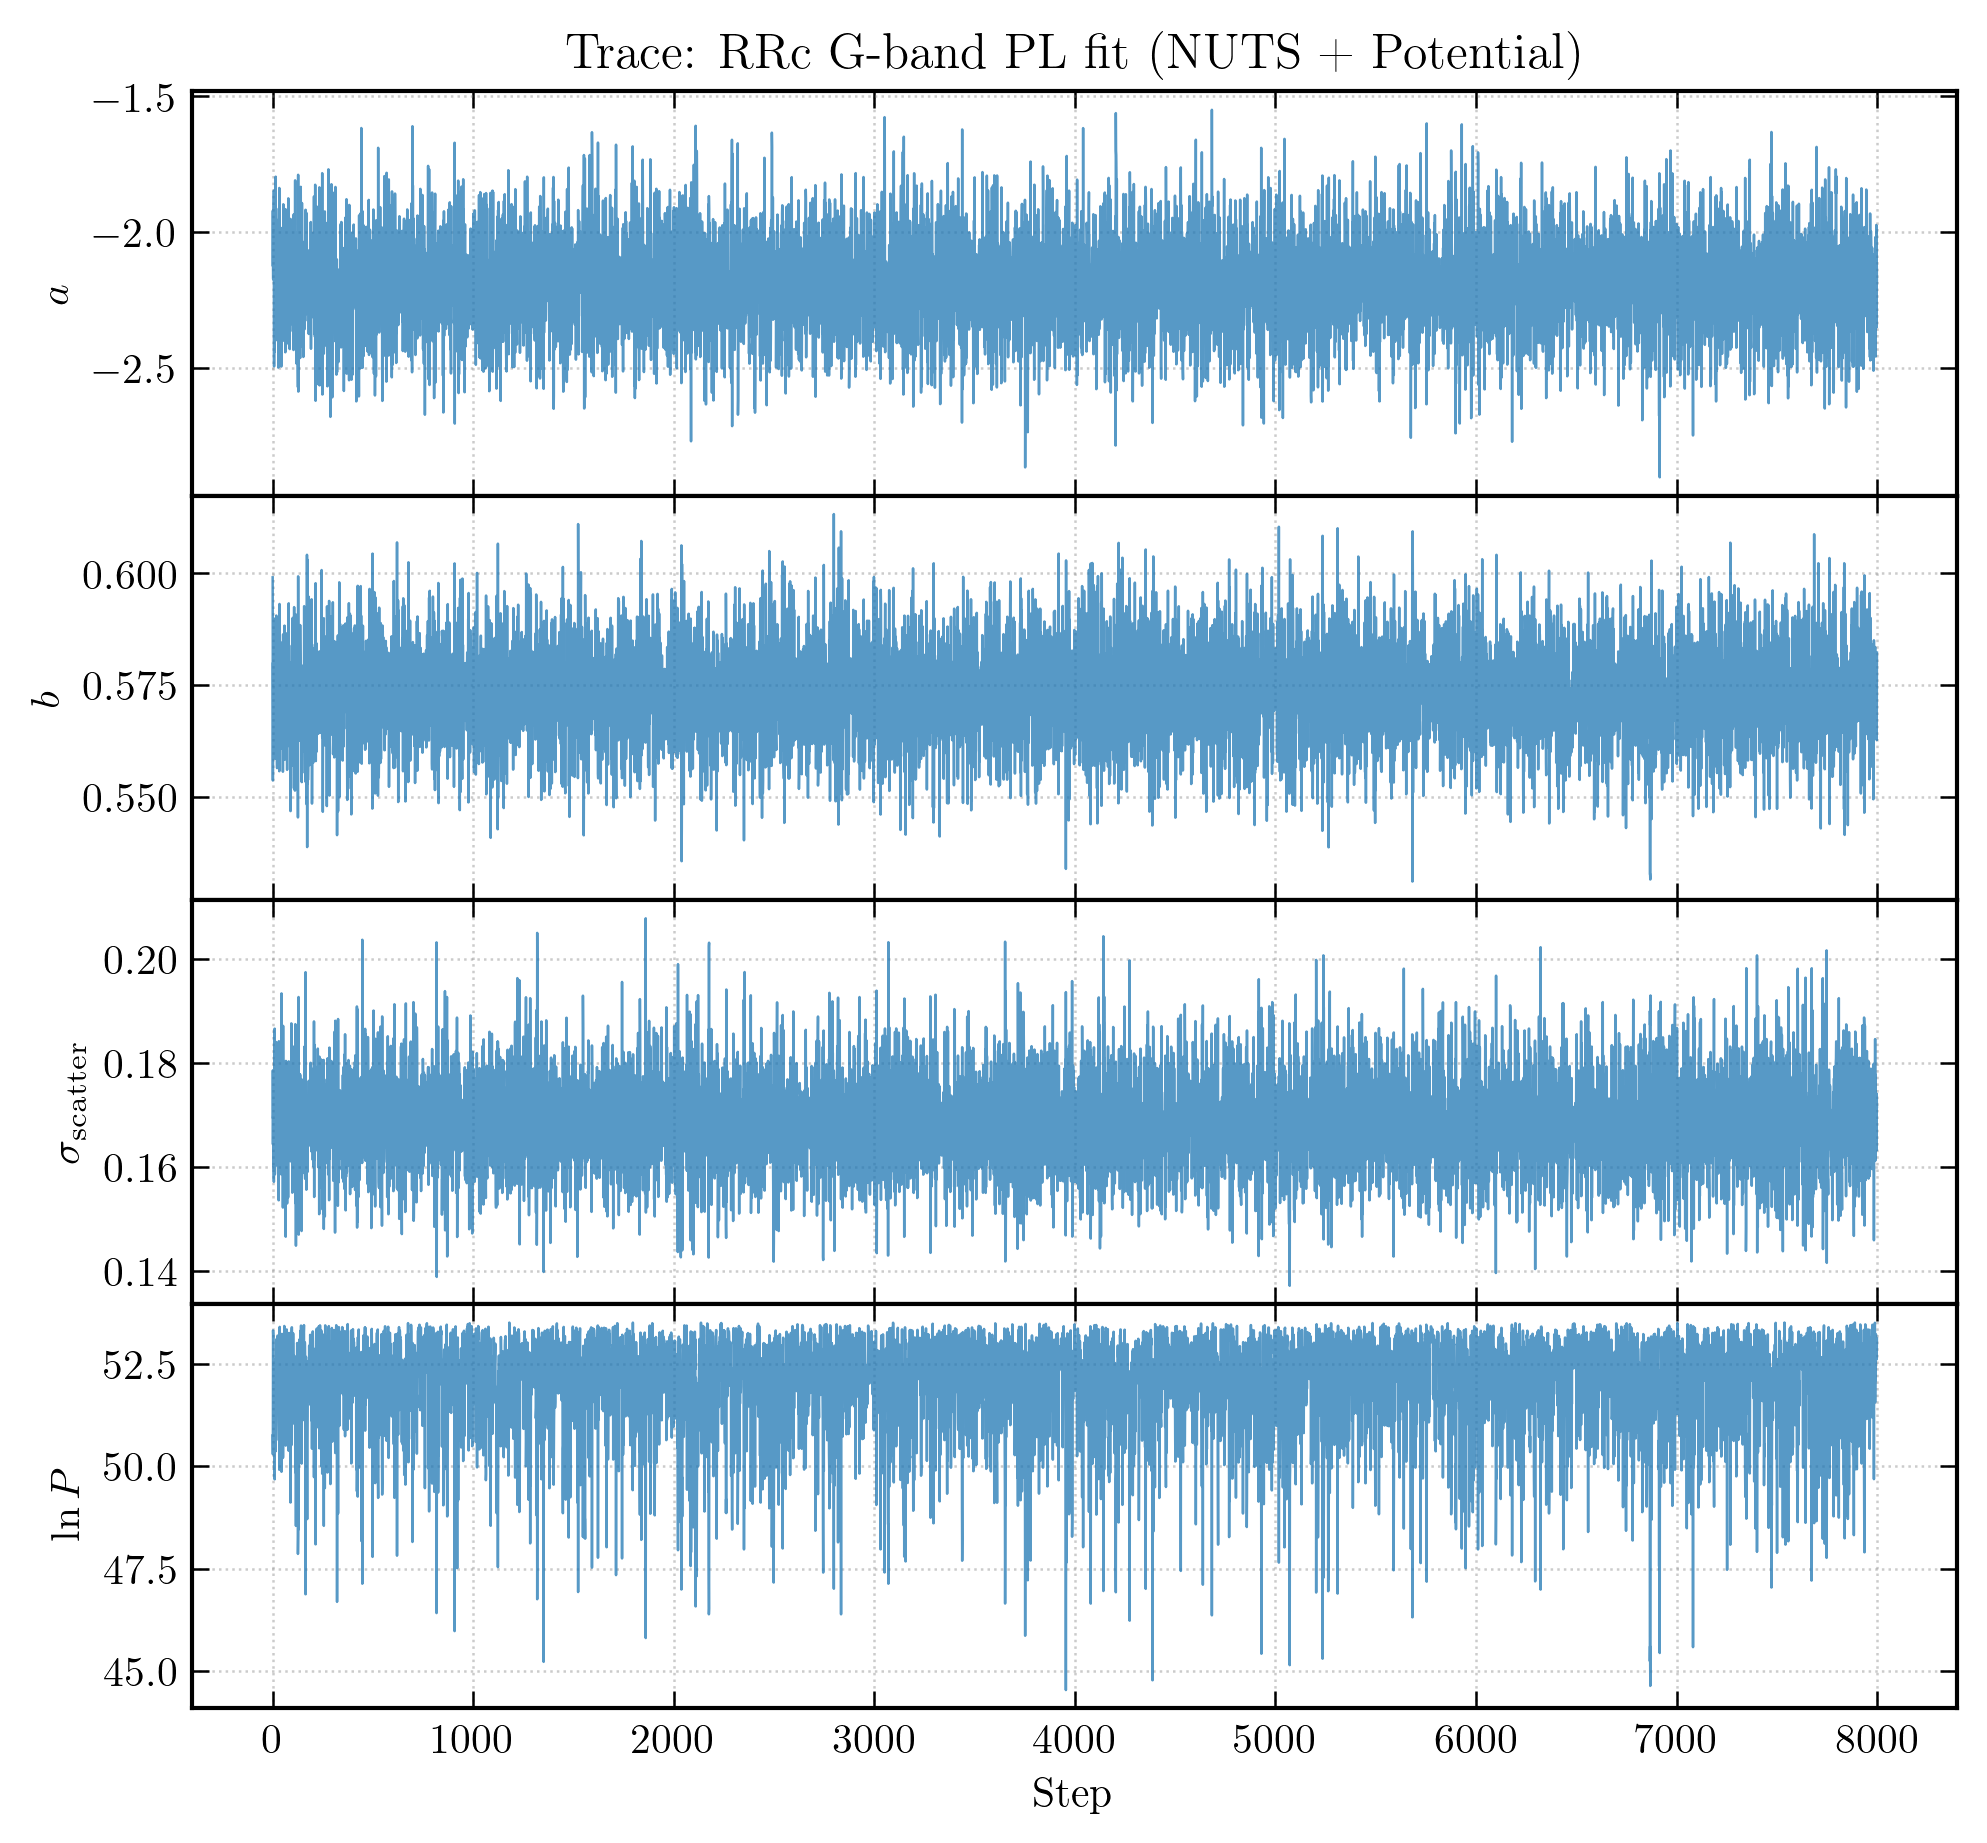

In [16]:
rrc_nuts_potential = fit_nuts_potential(rrc_ctx)

axes = plot_trace(to_display(rrc_nuts_potential))
axes[0].set_title("Trace: RRc G-band PL fit (NUTS + Potential)")
plt.show()

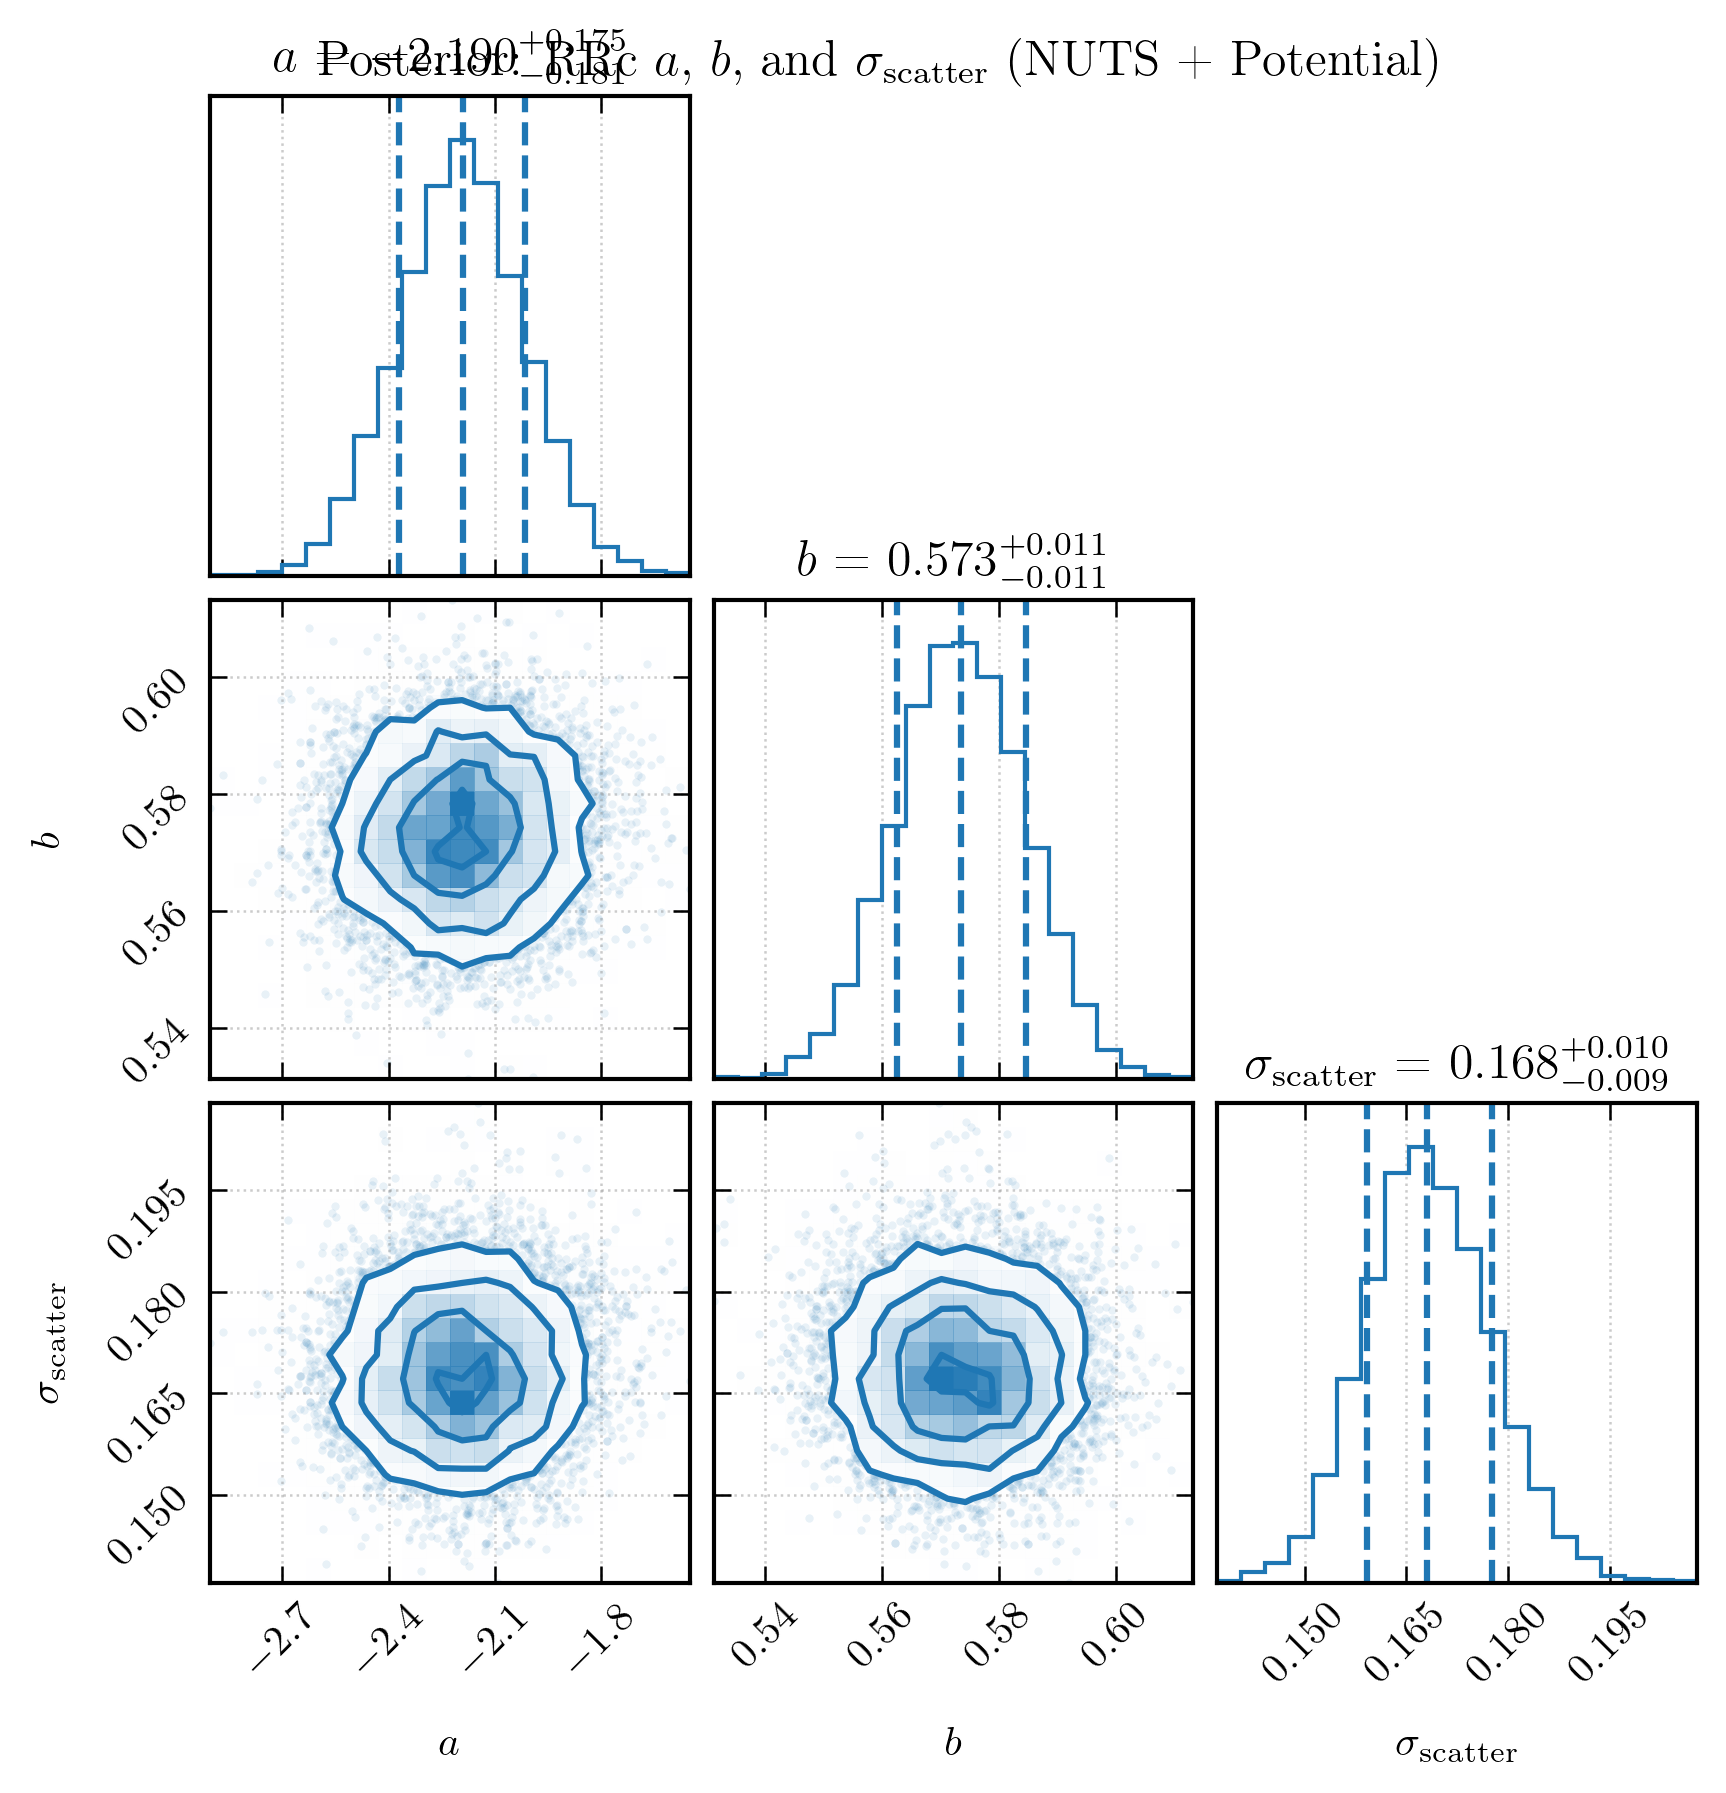

In [17]:
fig = plot_corner(to_display(rrc_nuts_potential))
fig.suptitle(r"Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (NUTS + Potential)")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


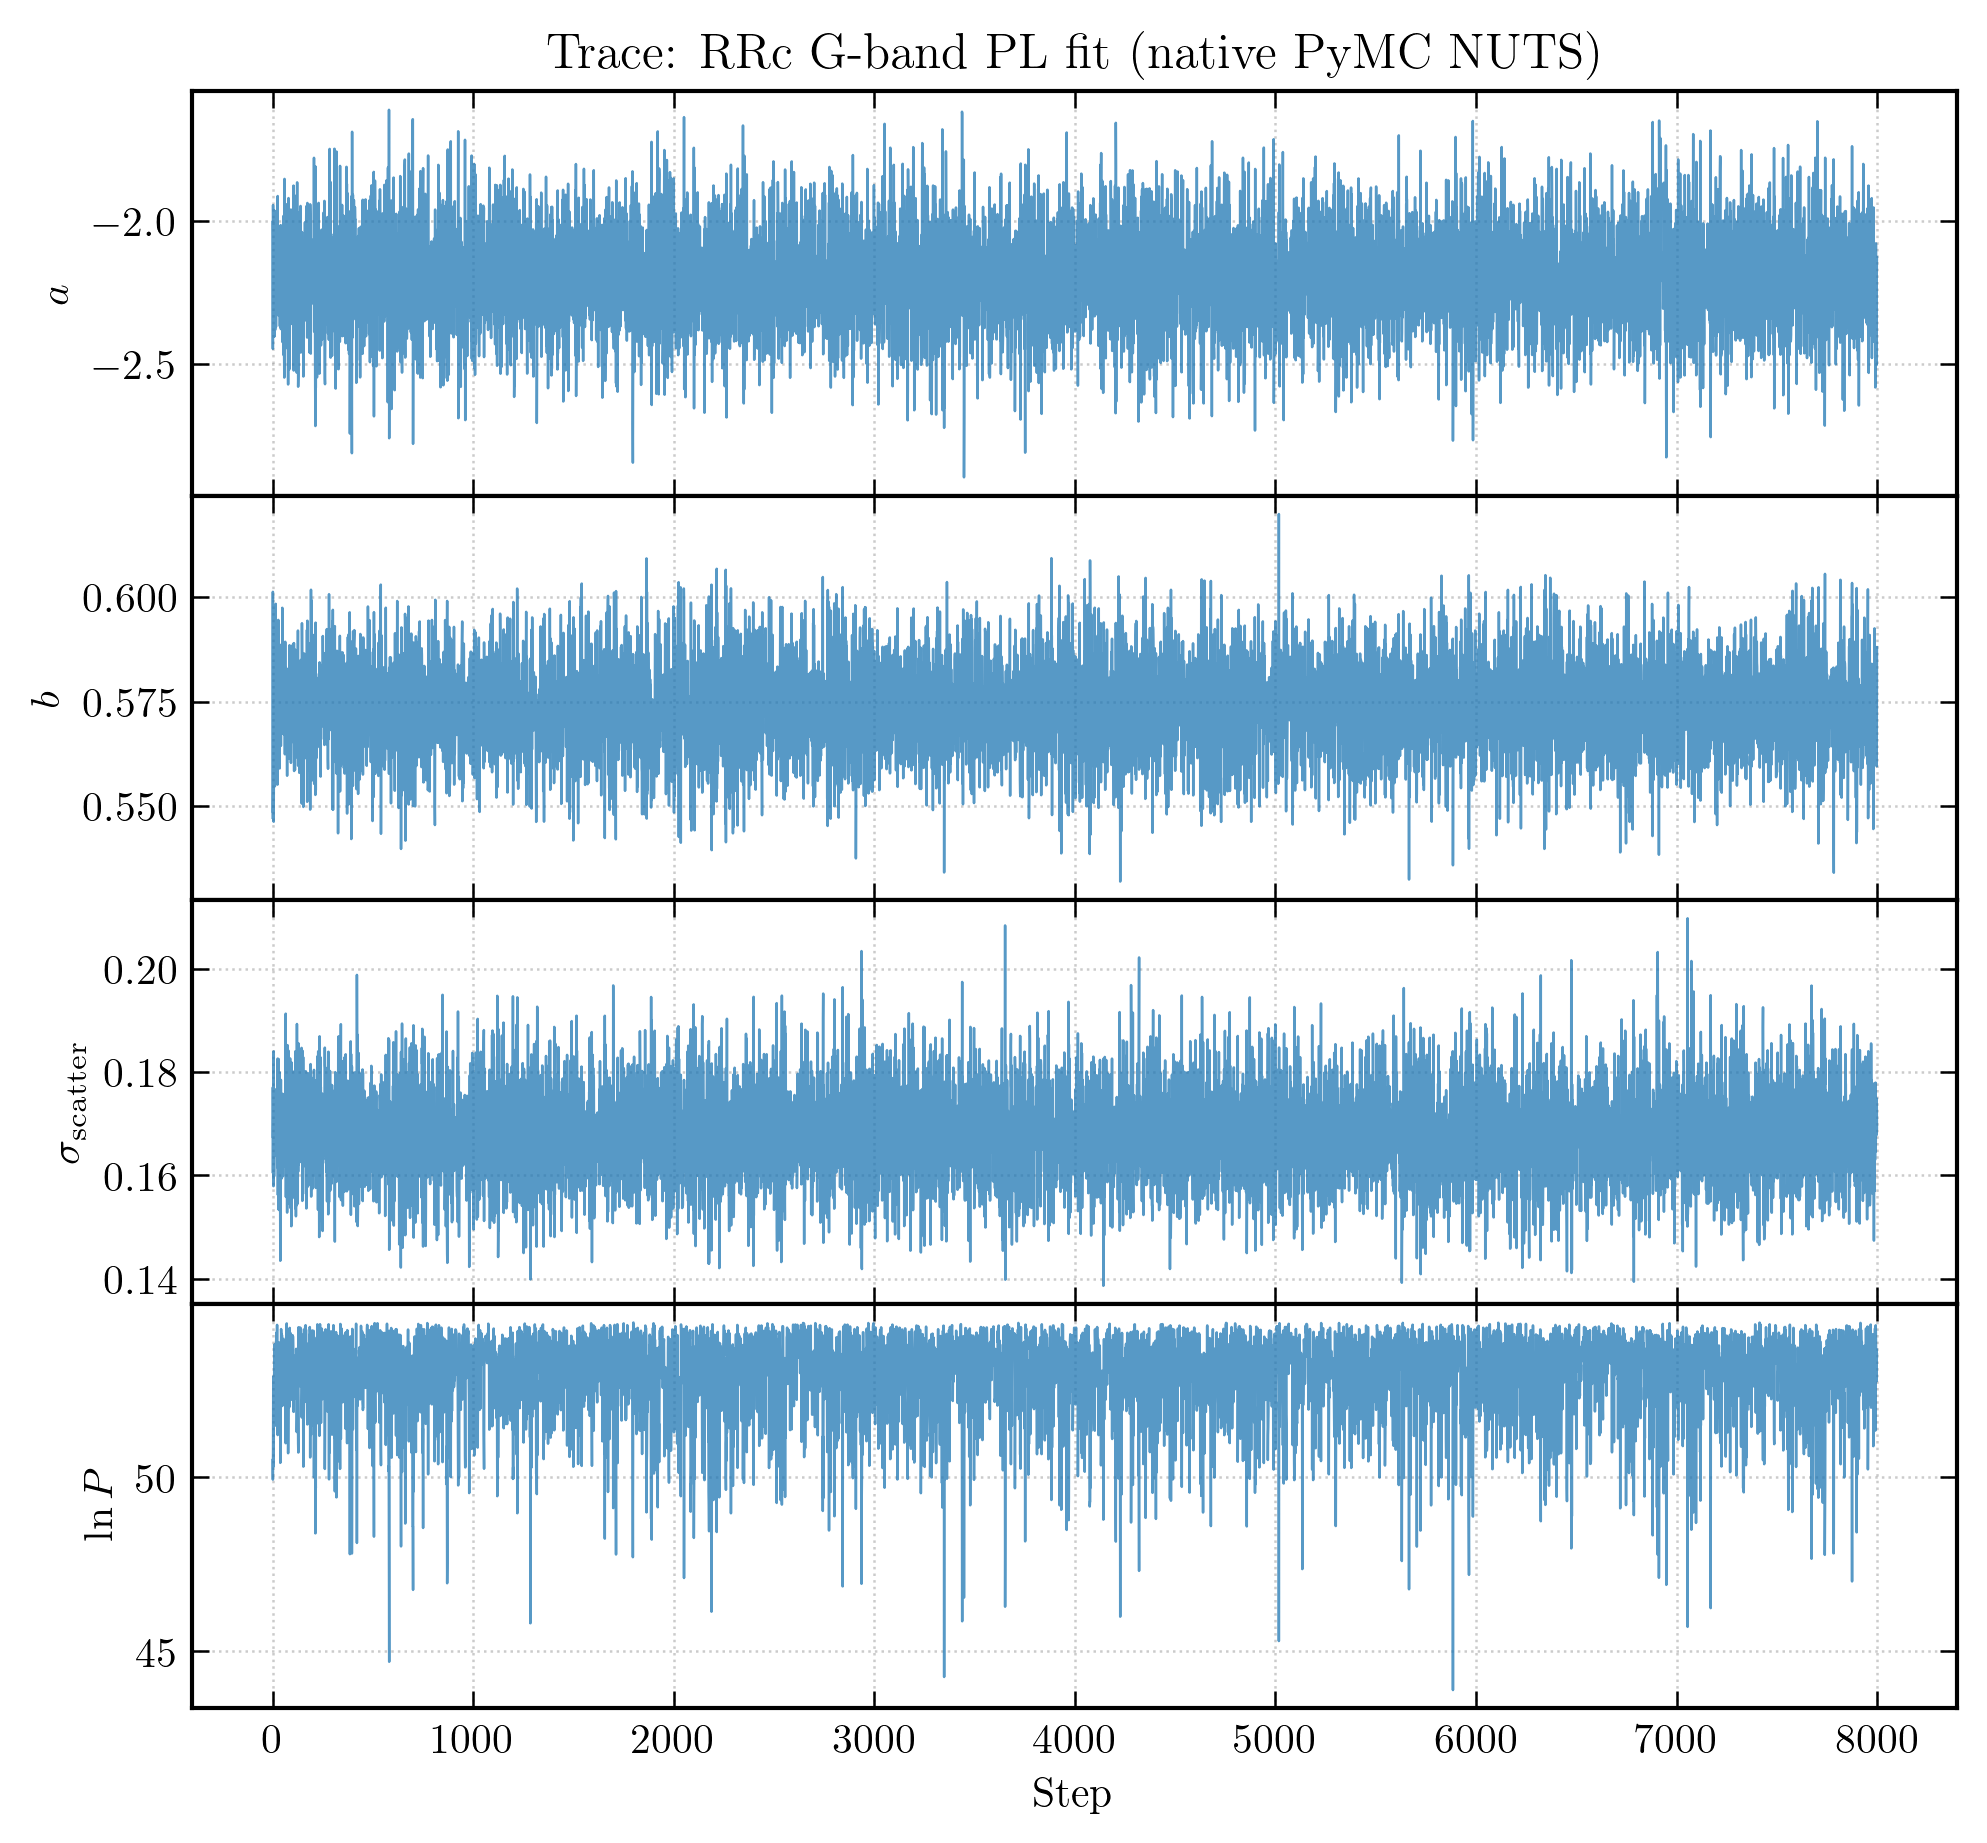

In [18]:
rrc_nuts_native = fit_nuts_native(rrc_ctx)

axes = plot_trace(to_display(rrc_nuts_native))
axes[0].set_title("Trace: RRc G-band PL fit (native PyMC NUTS)")
plt.show()

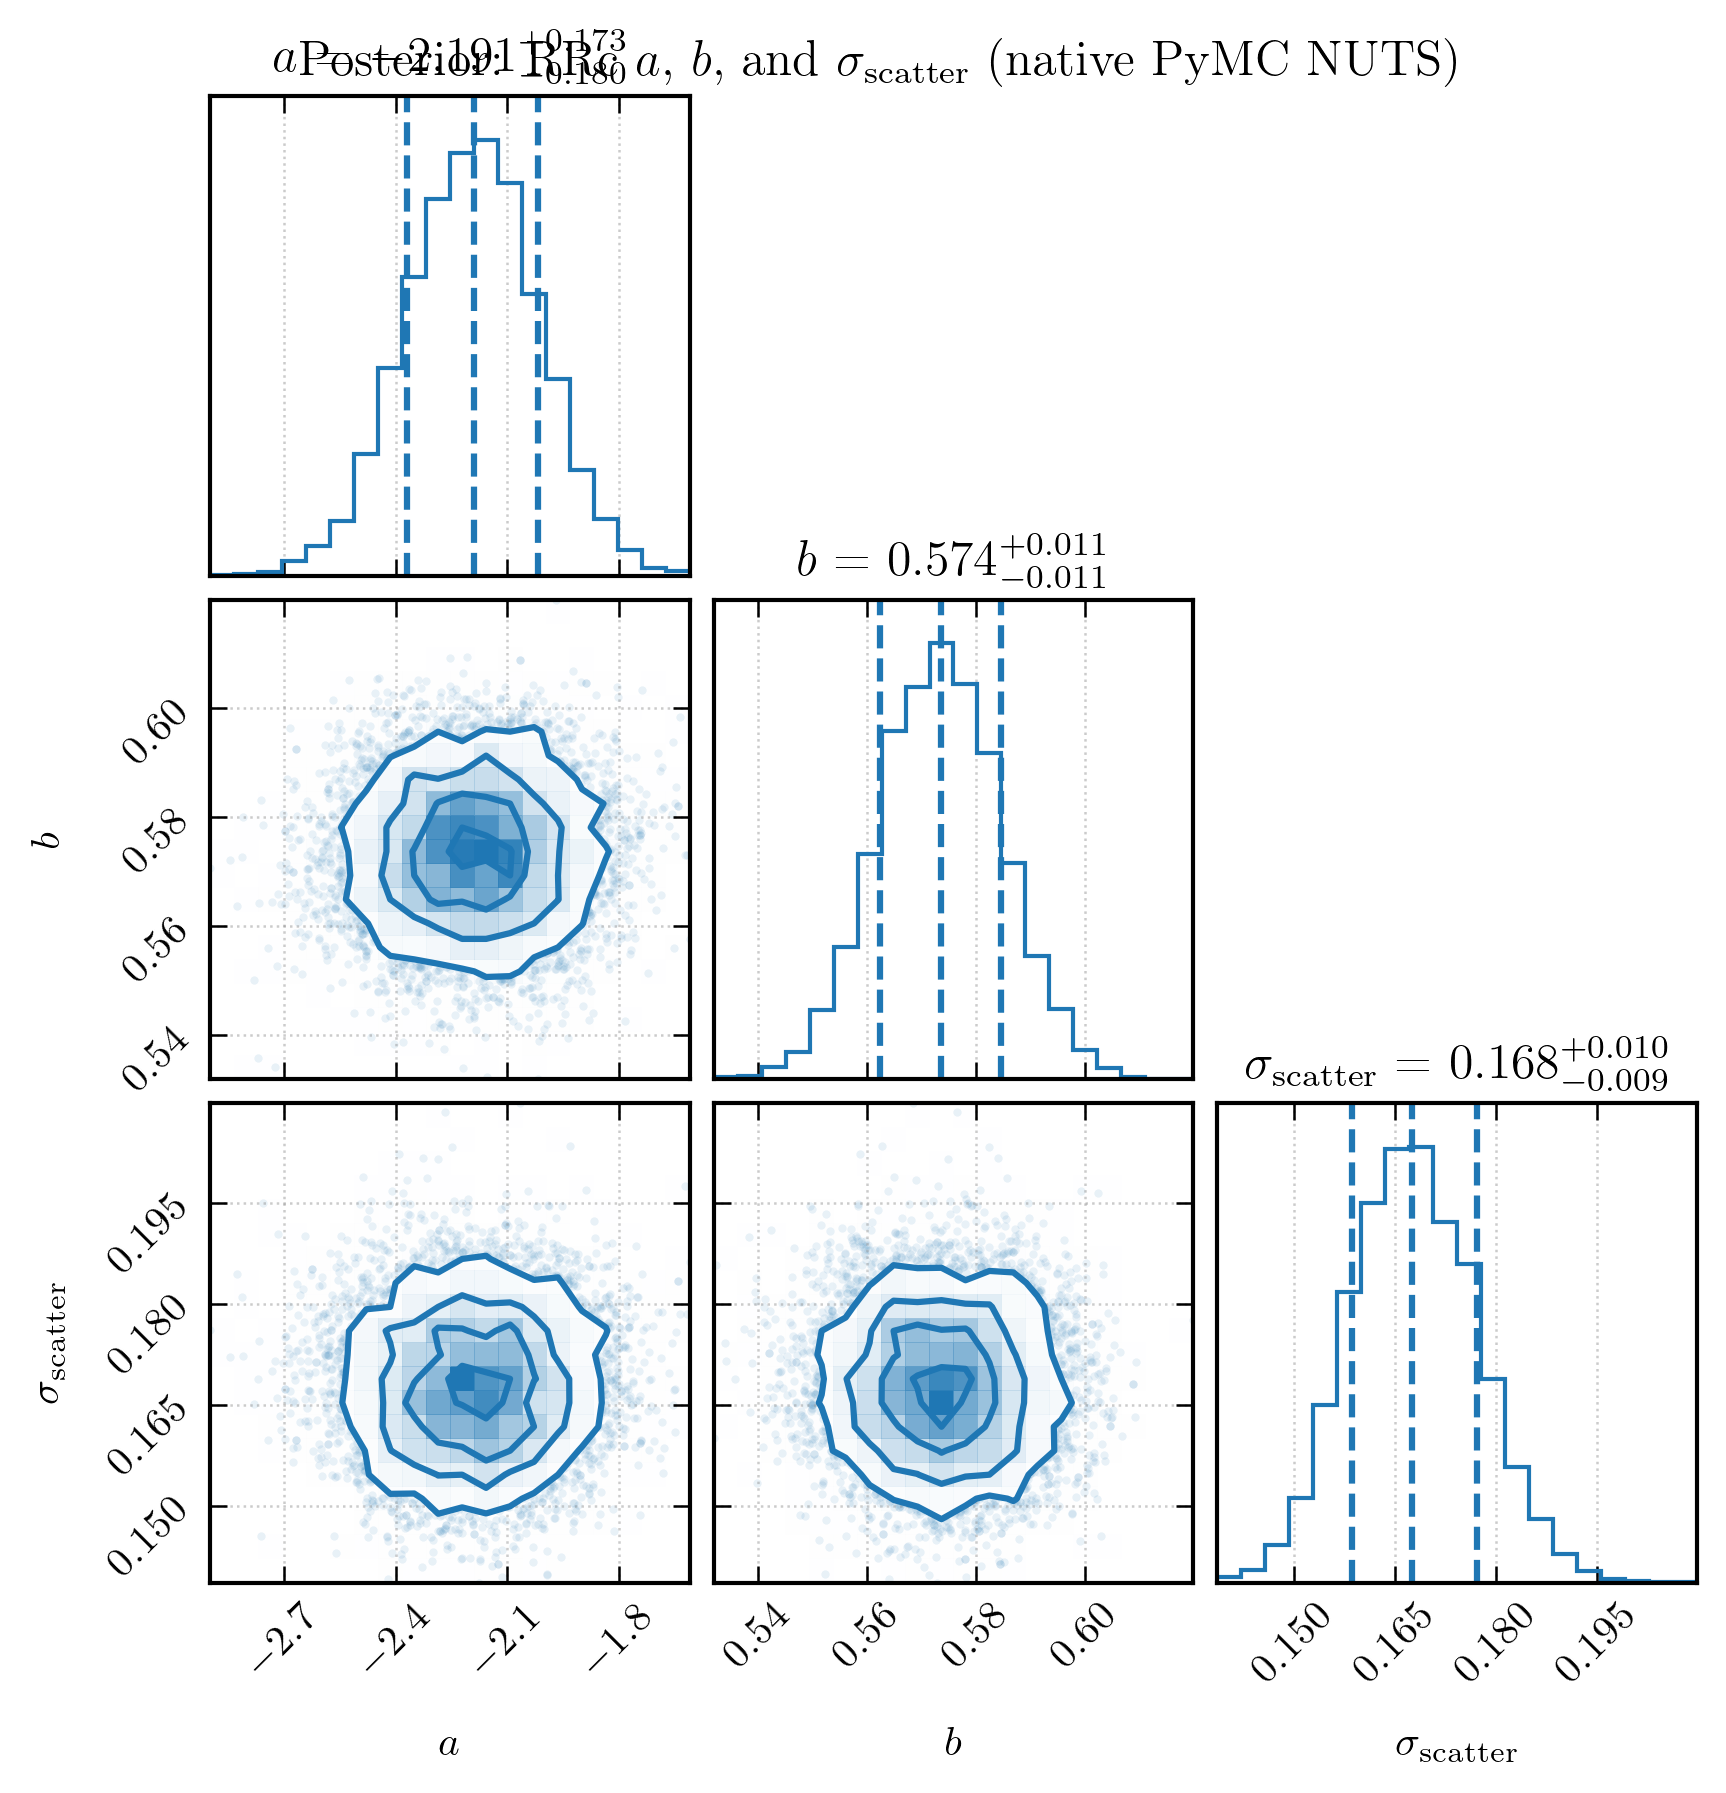

In [19]:
fig = plot_corner(to_display(rrc_nuts_native))
fig.suptitle(r"Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (native PyMC NUTS)")
plt.show()

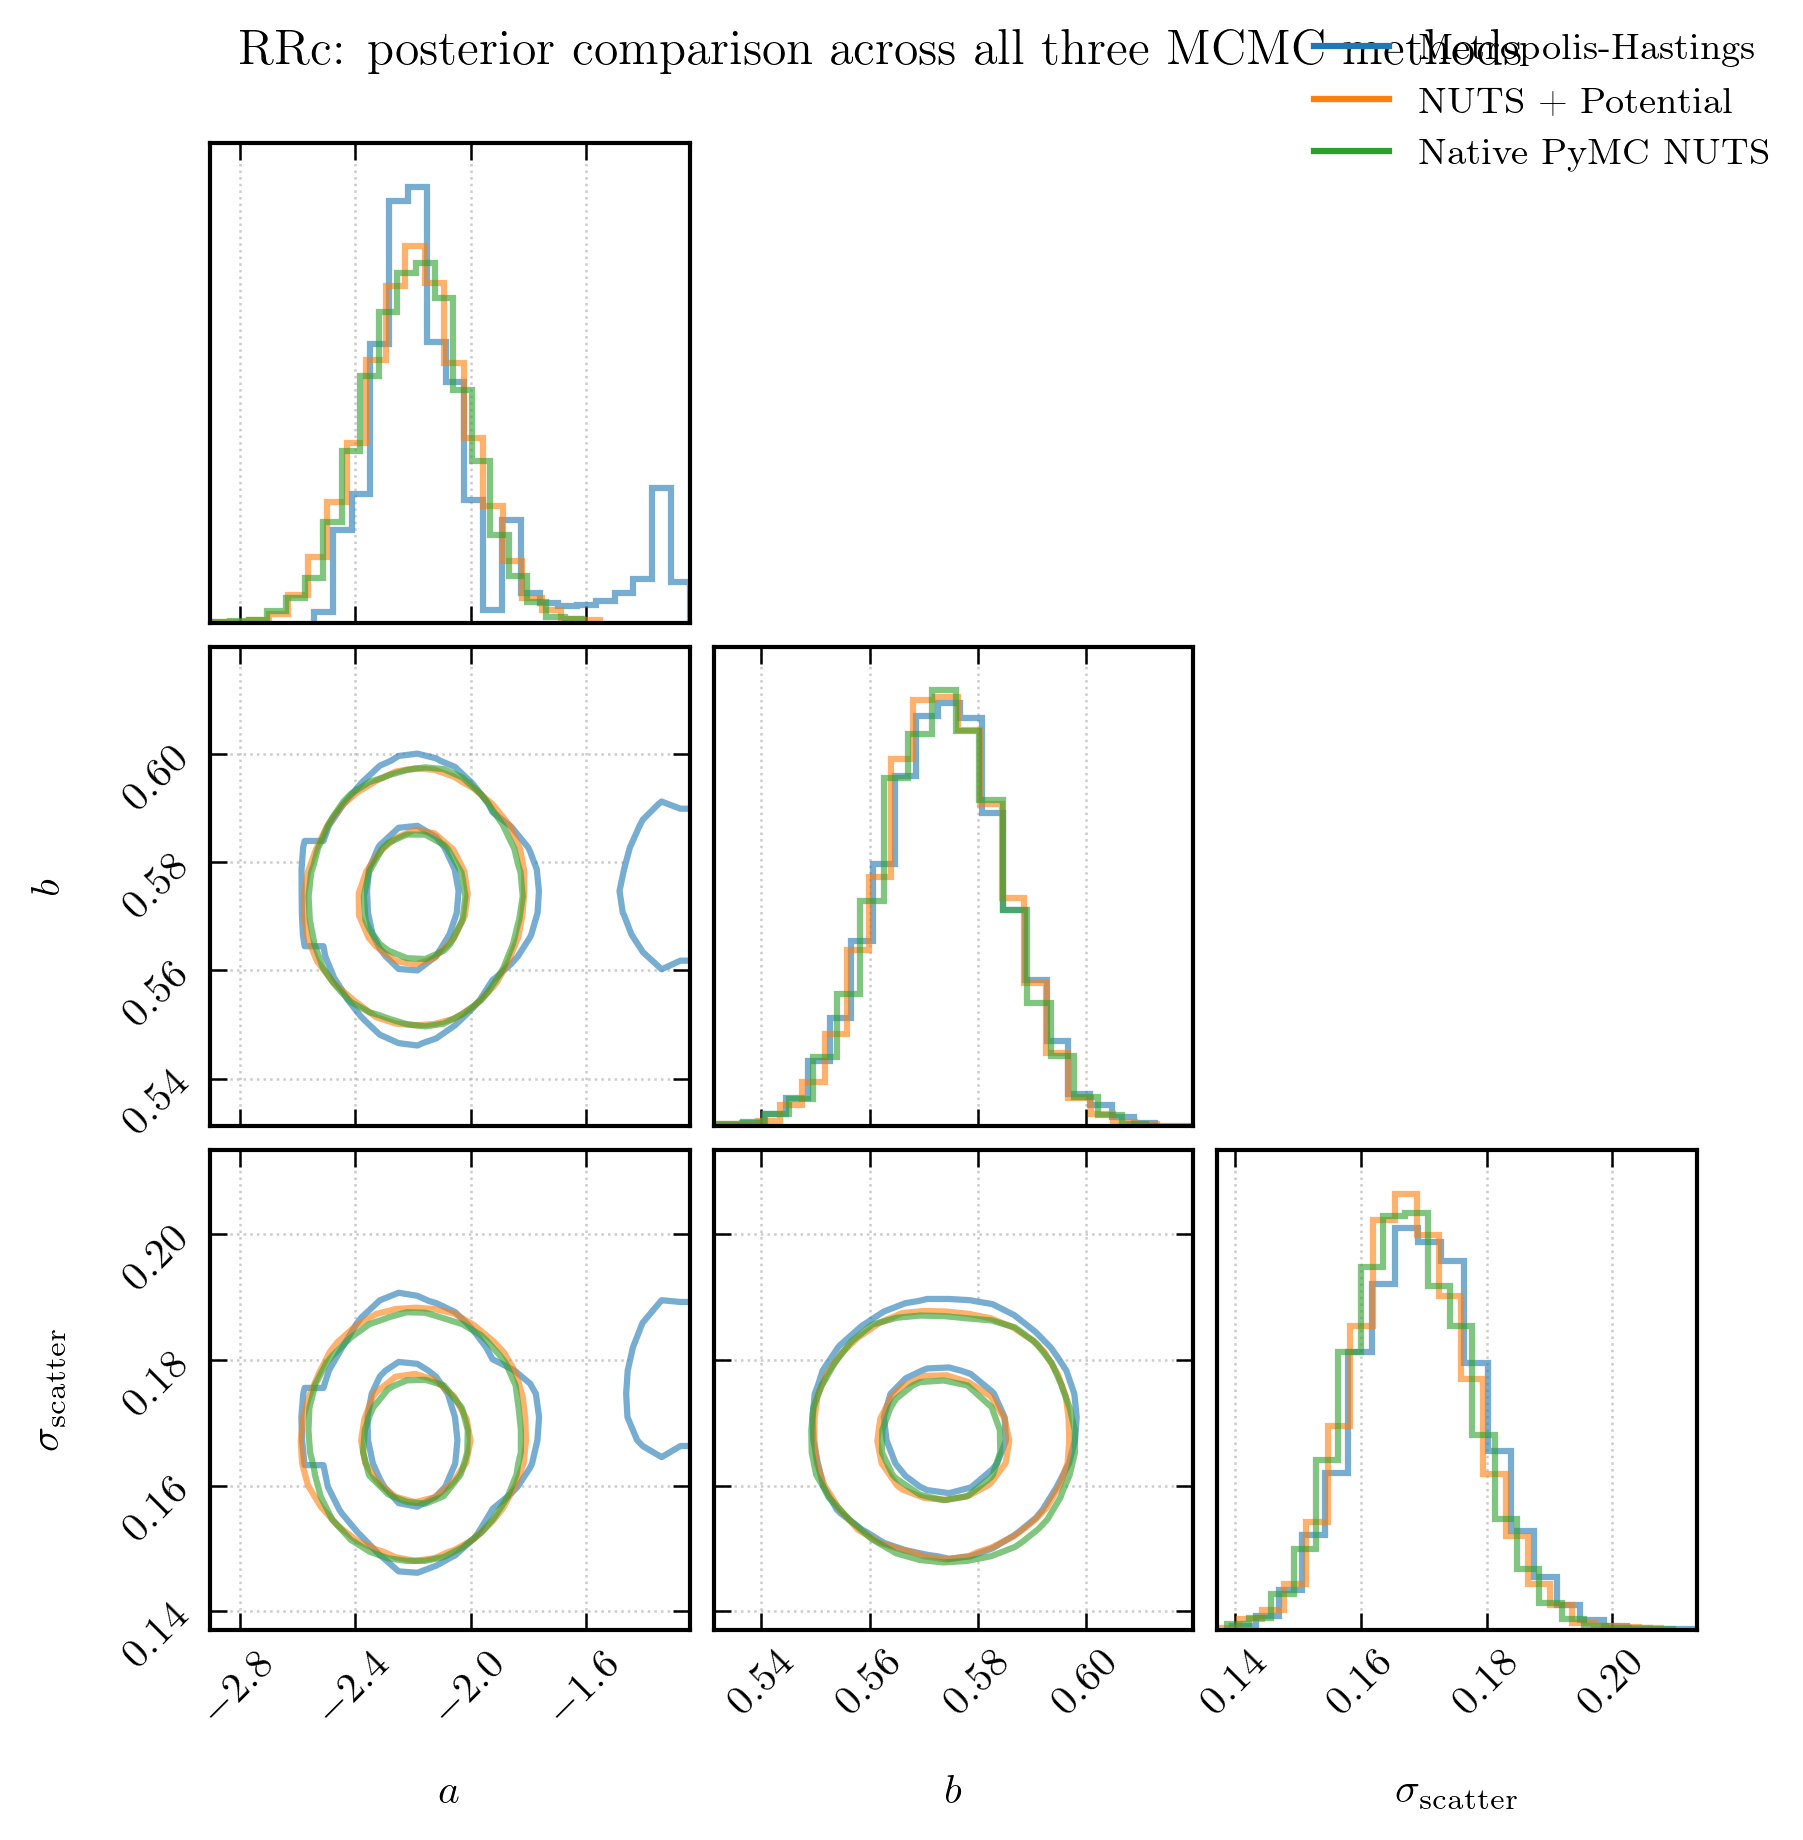

In [20]:
fig = plot_sampler_comparison_corner(
    {
        "Metropolis-Hastings": rrc_mh,
        "NUTS + Potential": to_display(rrc_nuts_potential),
        "Native PyMC NUTS": to_display(rrc_nuts_native),
    },
)
fig.suptitle(r"RRc: posterior comparison across all three MCMC methods", y=1.01)
_savefig(fig, "fig_methods_corner_rrc.pdf")
plt.show()

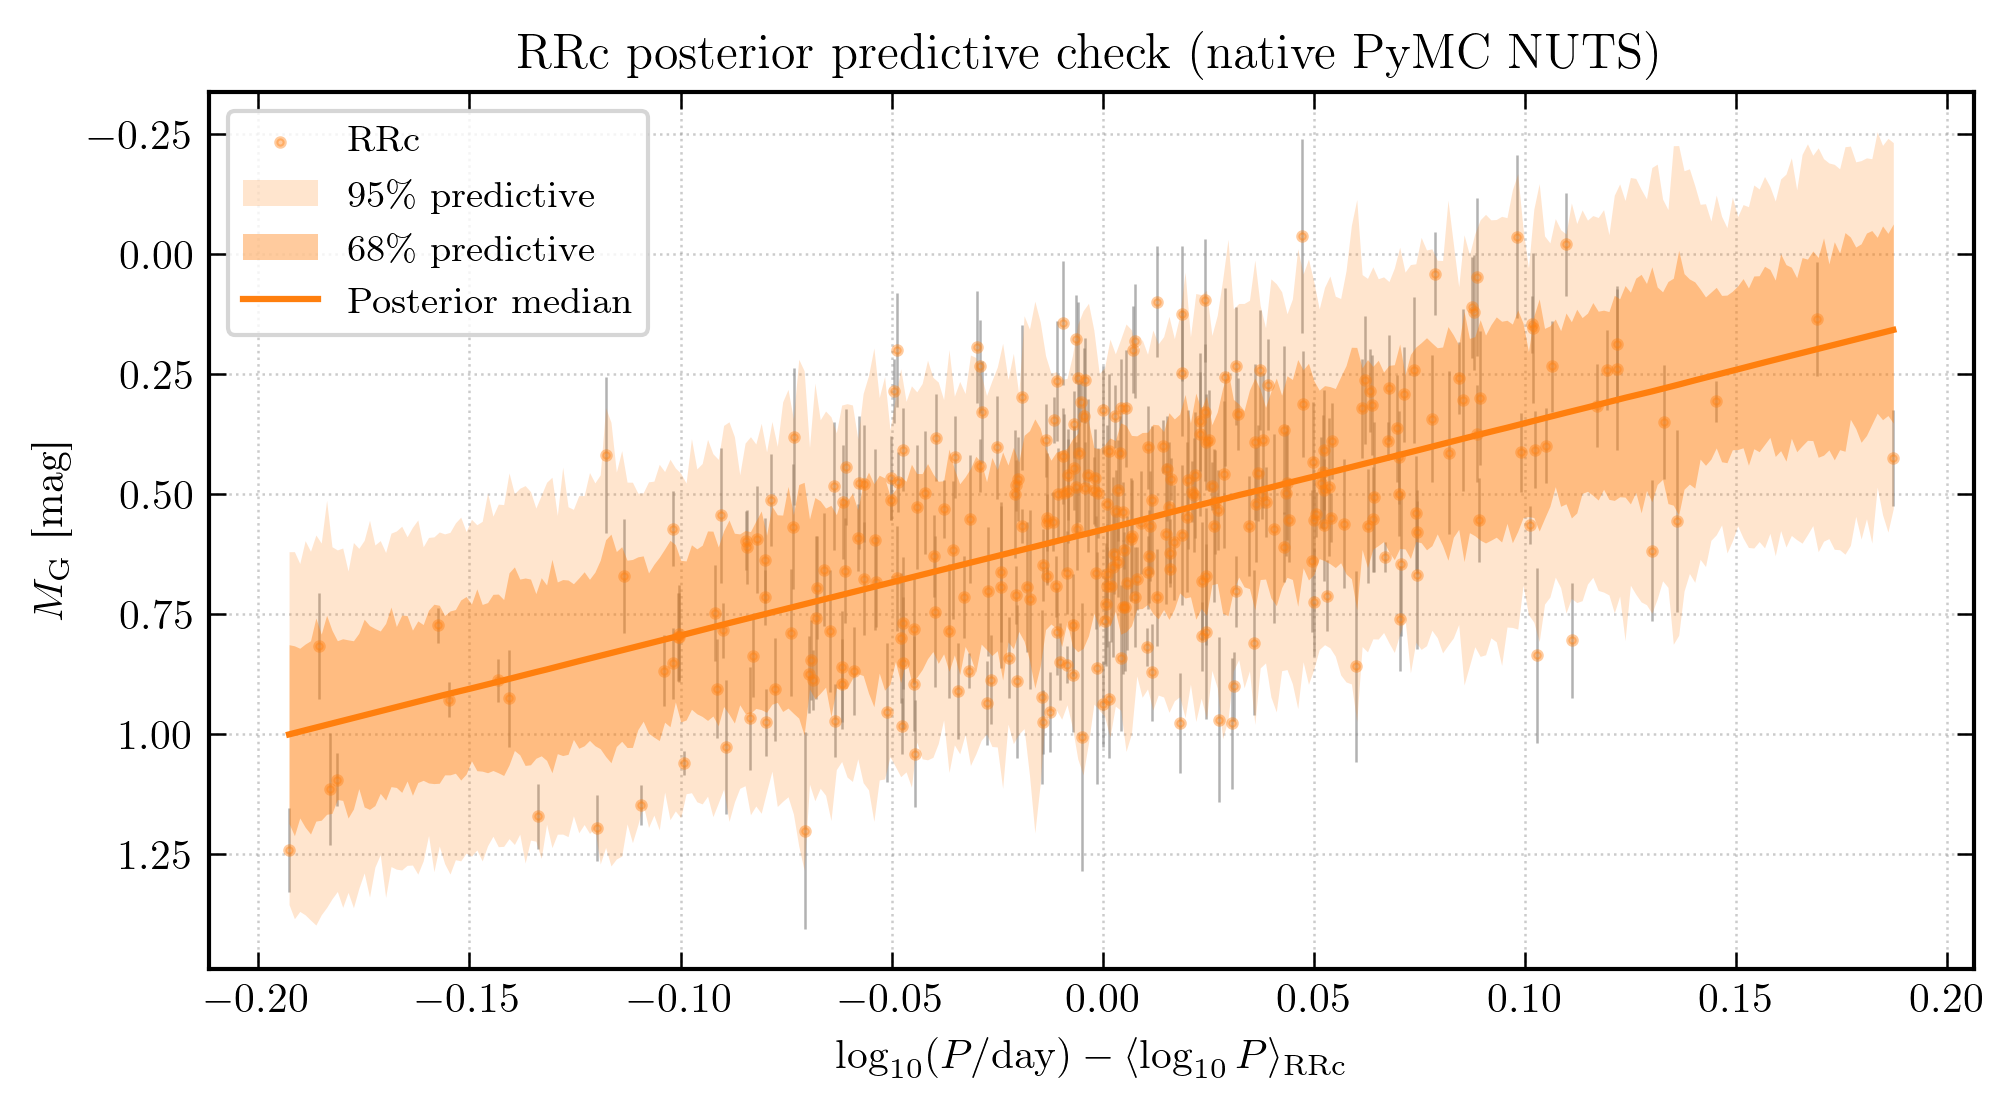

In [21]:
ax = plot_posterior_predictive(rrc_nuts_native, color="C1", data_label="RRc")
ax.set_xlabel(r"$\log_{10}(P/\mathrm{day}) - \langle \log_{10}P \rangle_{\rm RRc}$")
ax.set_ylabel(r"$M_{\rm G}$ [mag]")
ax.set_title("RRc posterior predictive check (native PyMC NUTS)")
_savefig(ax.figure, "fig_pl_posterior_rrc.pdf")
plt.show()

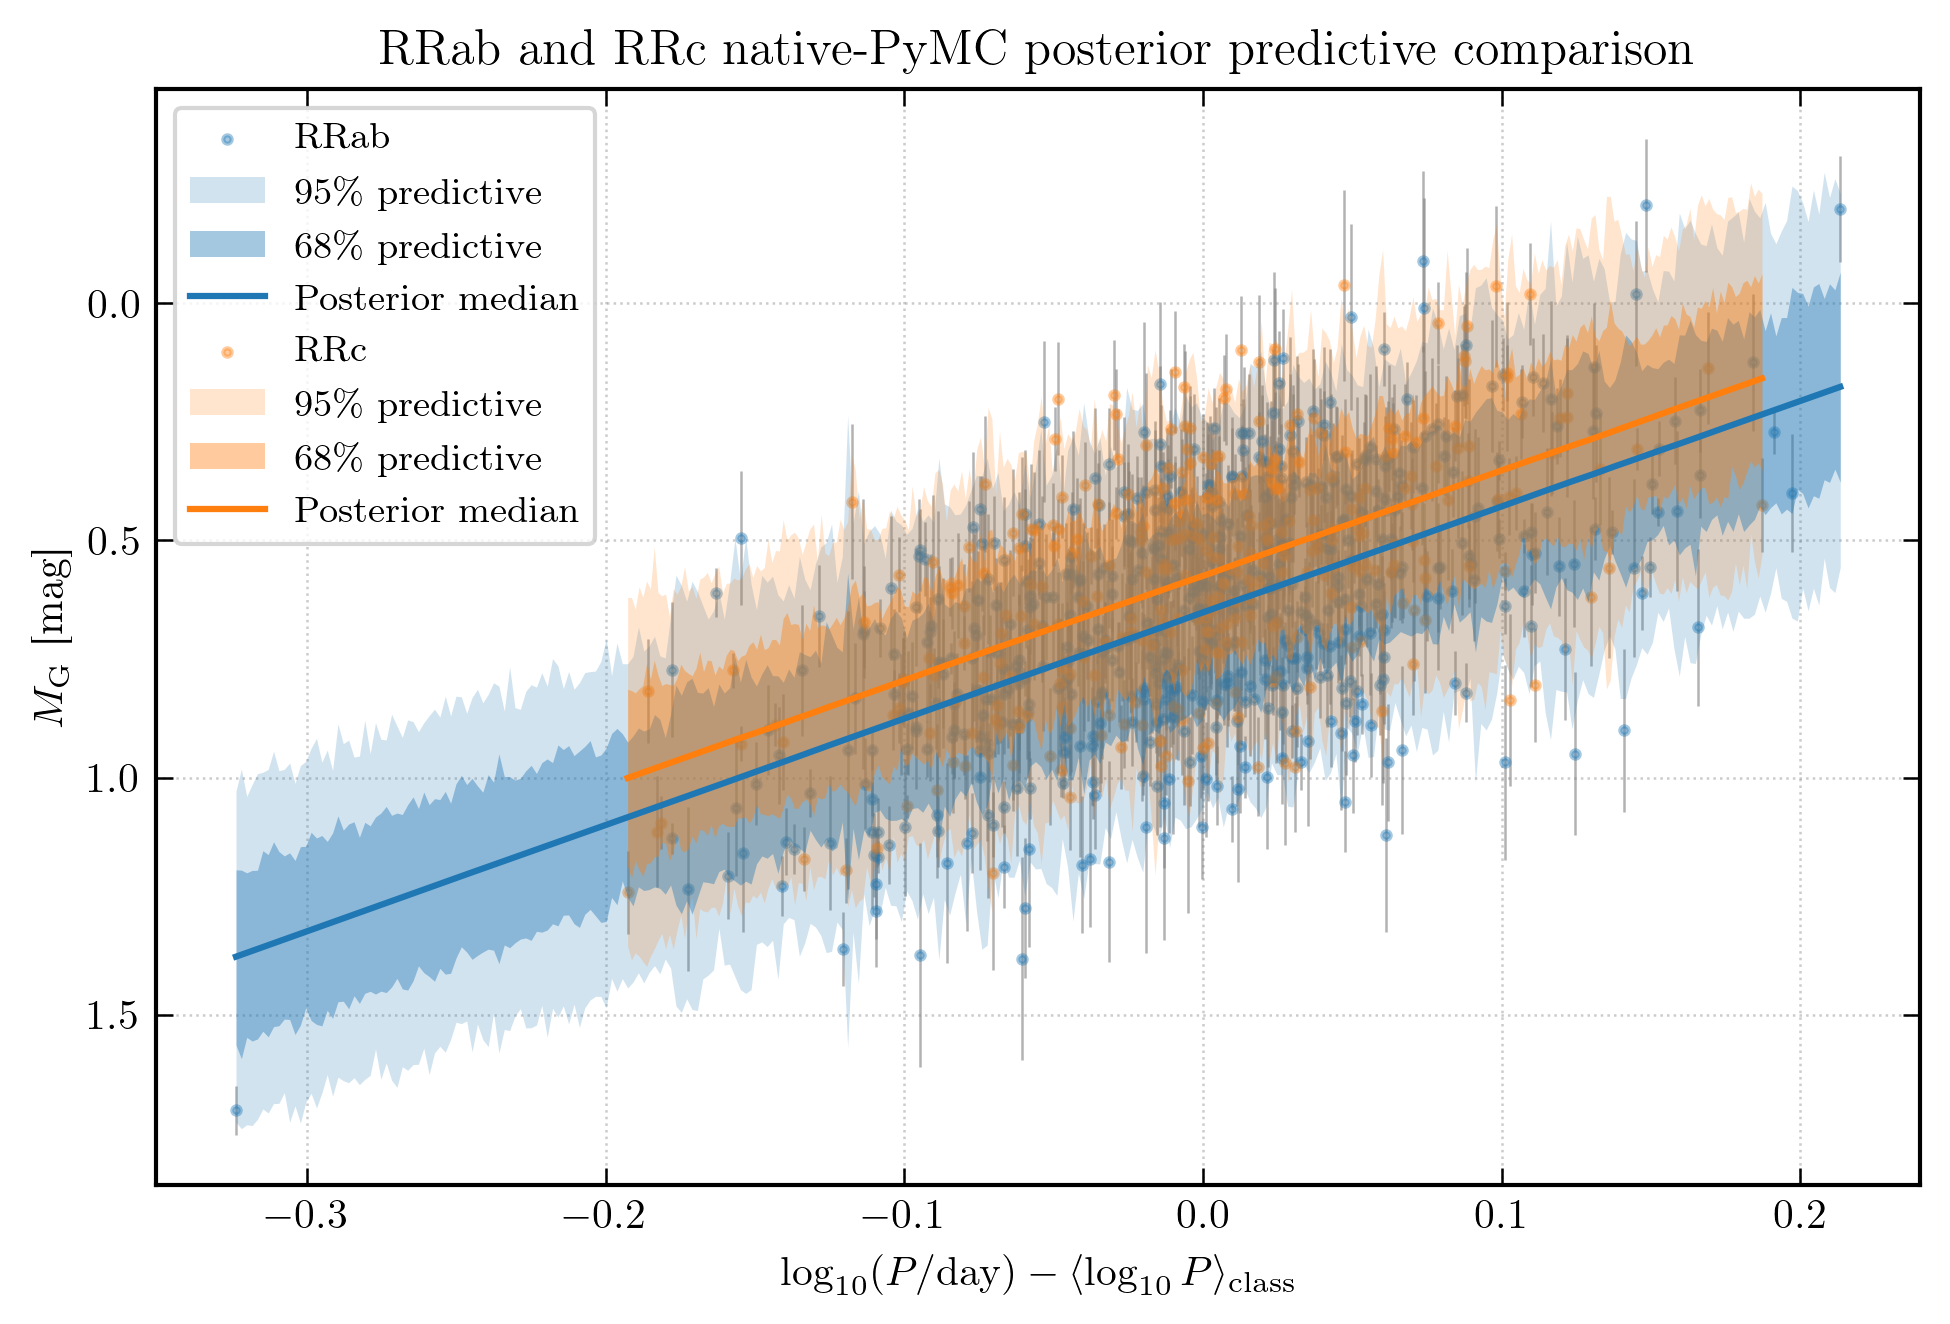

In [22]:
from ugdatalab.plotting import textwidth_figure

fig, ax = textwidth_figure(10)
plot_posterior_predictive(rrab_nuts_native, color="C0", data_label="RRab", ax=ax)
plot_posterior_predictive(rrc_nuts_native, color="C1", data_label="RRc", ax=ax)
ax.set_xlabel(r"$\log_{10}(P/\mathrm{day}) - \langle \log_{10}P \rangle_{\rm class}$")
ax.set_ylabel(r"$M_{\rm G}$ [mag]")
ax.set_title("RRab and RRc native-PyMC posterior predictive comparison")
plt.show()

In [23]:
output_path = Path("rrlyrae_optical_pl_comparison_data.npz")

# Export posterior summaries for downstream notebooks
rrab_med = np.median(rrab_nuts_native.samples, axis=0)
rrc_med = np.median(rrc_nuts_native.samples, axis=0)
np.savez_compressed(
    output_path,
    rrab_a=rrab_med[0], rrab_b=rrab_med[1], rrab_log10_sig=rrab_med[2],
    rrab_mean_log_p=rrab_ctx["mean_log_p"],
    rrab_samples=rrab_nuts_native.samples,
    rrc_a=rrc_med[0], rrc_b=rrc_med[1], rrc_log10_sig=rrc_med[2],
    rrc_mean_log_p=rrc_ctx["mean_log_p"],
    rrc_samples=rrc_nuts_native.samples,
)

{"path": str(output_path.resolve())}

{'path': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_optical_pl_comparison_data.npz'}